# SVM Baseline — SemEval 2016 Task 6

Replicates Mohammad et al. (2016) SVM-ngrams approach:
- One SVM classifier per target (5 classifiers total)
- Features: word n-grams (1–3) + character n-grams (2–5), TF-IDF weighted
- C tuned via 5-fold cross-validation
- Evaluation: 2-class Favg (paper metric) and 3-class macro F1 (LLM comparison)

**Known deviations from the paper:**
- Paper does not specify Twitter-specific preprocessing (hashtags, URLs); we use raw text
- Paper used SVM (likely dual-form); we use LinearSVC (primal L2) — equivalent for large feature spaces

## Step 1: Imports

In [86]:
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, precision_recall_fscore_support

## Step 2: Config

In [87]:
DATA_ROOT = Path("../data_in")
TRAIN_CSV = DATA_ROOT / "semeval2016_task6_stance.csv"
TEST_DIR  = DATA_ROOT / "semeval2016_task6_testdata_gold"

TARGETS = [
    "Atheism",
    "Climate Change is a Real Concern",
    "Feminist Movement",
    "Hillary Clinton",
    "Legalization of Abortion",
]

LABELS = ["FAVOR", "AGAINST", "NONE"]

# C values to search in cross-validation
C_GRID = [0.01, 0.1, 1, 10, 100]

## Step 3: Load Data

In [88]:
train_df = pd.read_csv(TRAIN_CSV)
train_df["stance_label_original"] = train_df["stance_label_original"].str.upper()

# Load test docs
test_records = []
for fpath in sorted(glob.glob(str(TEST_DIR / "*.json"))):
    with open(fpath) as f:
        test_records.append(json.load(f))
test_df = pd.DataFrame(test_records)
test_df["stance_label"] = test_df["stance_label"].str.upper()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print("Train targets:", train_df["query"].value_counts().to_dict())
print("Test targets: ", test_df["query"].value_counts().to_dict())

Train: 2814 rows | Test: 1249 rows
Train targets: {'Feminist Movement': 664, 'Hillary Clinton': 639, 'Legalization of Abortion': 603, 'Atheism': 513, 'Climate Change is a Real Concern': 395}
Test targets:  {'Hillary Clinton': 295, 'Feminist Movement': 285, 'Legalization of Abortion': 280, 'Atheism': 220, 'Climate Change is a Real Concern': 169}


## Step 3b: Training & Test Label Distribution

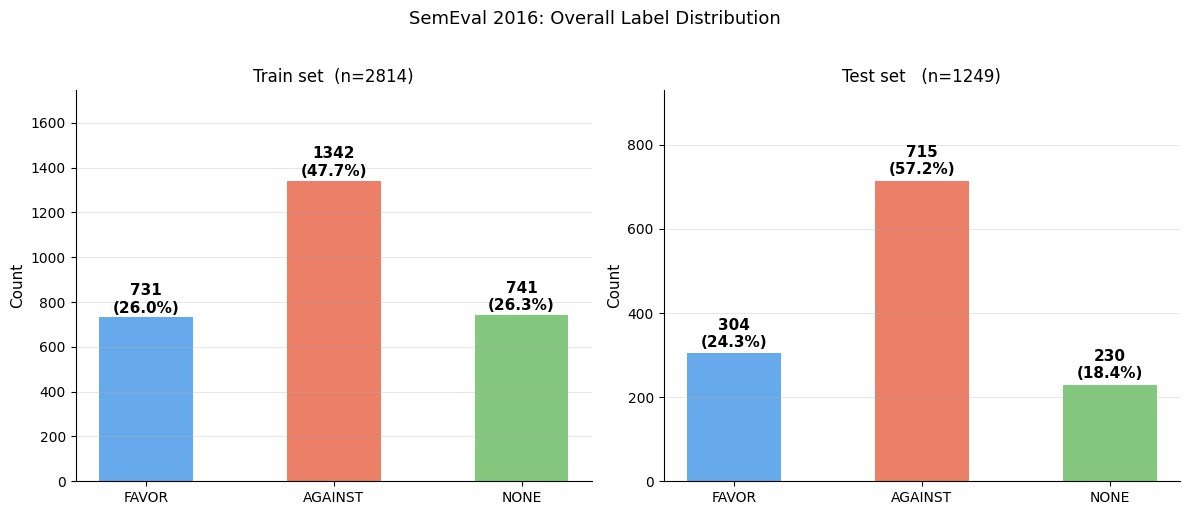

In [89]:
import matplotlib.pyplot as plt
import numpy as np

LABELS = ["FAVOR", "AGAINST", "NONE"]
COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

def label_counts(df, label_col):
    vc = df[label_col].value_counts()
    return {lbl: vc.get(lbl, 0) for lbl in LABELS}

train_counts = label_counts(train_df, "stance_label_original")
test_counts  = label_counts(test_df,  "stance_label")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, title in [
    (axes[0], train_counts, f"Train set  (n={sum(train_counts.values())})"),
    (axes[1], test_counts,  f"Test set   (n={sum(test_counts.values())})"),
]:
    total  = sum(counts.values())
    values = [counts[l] for l in LABELS]
    colors = [COLORS[l] for l in LABELS]
    bars   = ax.bar(LABELS, values, color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 8,
                f"{val}\n({val/total:.1%})",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.3)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("SemEval 2016: Overall Label Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 3c: SVM Predicted vs Gold Test Distribution

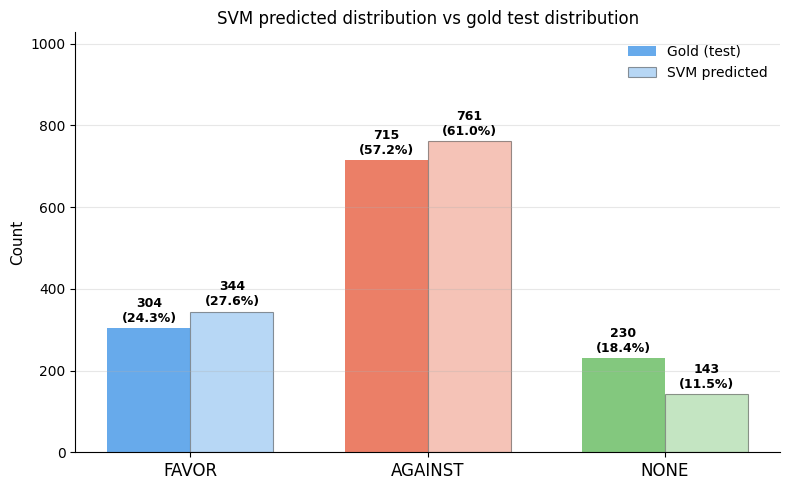

In [90]:
import matplotlib.pyplot as plt
import numpy as np

LABELS = ["FAVOR", "AGAINST", "NONE"]
COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

# SVM predicted counts: predicted_count = R * N_true / P
svm_counts = {
    "FAVOR":   round((0.658 * 304) / 0.581),
    "AGAINST": round((0.787 * 715) / 0.739),
    "NONE":    round((0.322 * 230) / 0.517),
}
svm_total  = sum(svm_counts.values())
test_total = sum(test_counts.values())

x     = np.arange(len(LABELS))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_gold = ax.bar(x - bar_w/2, [test_counts[l] for l in LABELS], width=bar_w,
                   color=[COLORS[l] for l in LABELS], alpha=0.85, label="Gold (test)")
bars_svm  = ax.bar(x + bar_w/2, [svm_counts[l]  for l in LABELS], width=bar_w,
                   color=[COLORS[l] for l in LABELS], alpha=0.4,
                   edgecolor="black", linewidth=0.8, label="SVM predicted")

for bars, counts, total in [(bars_gold, test_counts, test_total),
                             (bars_svm,  svm_counts,  svm_total)]:
    for bar, lbl in zip(bars, LABELS):
        val = counts[lbl]
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 8,
                f"{val}\n({val/total:.1%})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

all_vals = [test_counts[l] for l in LABELS] + [svm_counts[l] for l in LABELS]
ax.set_ylim(0, max(all_vals) * 1.35)
ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=12)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=10, frameon=False)
ax.set_title("SVM predicted distribution vs gold test distribution", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Step 4: Feature Extraction Helpers

Two TF-IDF vectorizers concatenated:
- Word n-grams (1–3)
- Character n-grams (2–5)

In [91]:
def build_features(train_texts, test_texts):
    """Return (X_train, X_test) sparse matrices with word + char ngram TF-IDF."""
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=1,
    )
    char_vec = TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        min_df=1,
    )

    X_train_word = word_vec.fit_transform(train_texts)
    X_test_word  = word_vec.transform(test_texts)

    X_train_char = char_vec.fit_transform(train_texts)
    X_test_char  = char_vec.transform(test_texts)

    X_train = hstack([X_train_word, X_train_char])
    X_test  = hstack([X_test_word,  X_test_char])
    return X_train, X_test

## Step 5: Metrics

- **2-class Favg** (paper metric): average of F1_FAVOR and F1_AGAINST, where NONE is treated as the negative class for each binary calculation.
- **3-class macro F1**: standard macro-averaged F1 over FAVOR / AGAINST / NONE.

In [92]:
def two_class_favg(y_true, y_pred):
    """SemEval 2016 Task 6 official metric: (F1_FAVOR + F1_AGAINST) / 2."""
    f_favor   = f1_score(y_true, y_pred, labels=["FAVOR"],   average="macro", zero_division=0)
    f_against = f1_score(y_true, y_pred, labels=["AGAINST"], average="macro", zero_division=0)
    return (f_favor + f_against) / 2

def three_class_macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=["FAVOR", "AGAINST", "NONE"], average="macro", zero_division=0)

## Step 6: Train and Evaluate — SVM_F2_tuned (C selected by 2-class Favg)

This is the SemEval-style baseline: CV metric matches the paper's official 2-class Favg.
Kept for historical comparability with Mohammad et al. (2016).

In [93]:
results = []
all_preds = []

for target in TARGETS:
    tr = train_df[train_df["query"] == target].copy()
    te = test_df[test_df["query"] == target].copy()

    if len(tr) == 0 or len(te) == 0:
        print(f"Skipping {target}: no data")
        continue

    X_train, X_test = build_features(tr["content"].tolist(), te["content"].tolist())
    y_train = tr["stance_label_original"].tolist()
    y_test  = te["stance_label"].tolist()

    # 5-fold CV to tune C
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_c, best_cv_score = 1.0, -1
    for c in C_GRID:
        fold_scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            clf = LinearSVC(C=c, max_iter=2000, random_state=42)
            clf.fit(X_train[train_idx], [y_train[i] for i in train_idx])
            val_preds = clf.predict(X_train[val_idx])
            val_true  = [y_train[i] for i in val_idx]
            fold_scores.append(two_class_favg(val_true, val_preds))
        mean_score = np.mean(fold_scores)
        if mean_score > best_cv_score:
            best_cv_score = mean_score
            best_c = c

    # Train on full training set with best C
    clf = LinearSVC(C=best_c, max_iter=2000, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    favg    = two_class_favg(y_test, y_pred)
    macro3  = three_class_macro_f1(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"Target: {target}")
    print(f"  Best C (CV): {best_c}   CV Favg: {best_cv_score:.4f}")
    print(f"  Test 2-class Favg:    {favg:.4f}")
    print(f"  Test 3-class Macro F1:{macro3:.4f}")
    print(classification_report(y_test, y_pred, labels=["FAVOR", "AGAINST", "NONE"], zero_division=0))

    results.append({"target": target, "best_C": best_c, "2class_favg": favg, "3class_macro_f1": macro3})
    for true, pred in zip(y_test, y_pred):
        all_preds.append({"target": target, "true": true, "pred": pred})

/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Atheism
  Best C (CV): 10   CV Favg: 0.6223
  Test 2-class Favg:    0.5778
  Test 3-class Macro F1:0.4703
              precision    recall  f1-score   support

       FAVOR       0.39      0.28      0.33        32
     AGAINST       0.79      0.88      0.83       160
        NONE       0.32      0.21      0.26        28

    accuracy                           0.70       220
   macro avg       0.50      0.46      0.47       220
weighted avg       0.67      0.70      0.68       220



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Climate Change is a Real Concern
  Best C (CV): 1   CV Favg: 0.5451
  Test 2-class Favg:    0.4338
  Test 3-class Macro F1:0.4468
              precision    recall  f1-score   support

       FAVOR       0.79      0.96      0.87       123
     AGAINST       0.00      0.00      0.00        11
        NONE       0.65      0.37      0.47        35

    accuracy                           0.78       169
   macro avg       0.48      0.44      0.45       169
weighted avg       0.71      0.78      0.73       169



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Feminist Movement
  Best C (CV): 100   CV Favg: 0.6149
  Test 2-class Favg:    0.5913
  Test 3-class Macro F1:0.4977
              precision    recall  f1-score   support

       FAVOR       0.36      0.71      0.48        58
     AGAINST       0.76      0.66      0.71       183
        NONE       0.64      0.20      0.31        44

    accuracy                           0.60       285
   macro avg       0.59      0.52      0.50       285
weighted avg       0.66      0.60      0.60       285



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Hillary Clinton
  Best C (CV): 1   CV Favg: 0.5183
  Test 2-class Favg:    0.5550
  Test 3-class Macro F1:0.5395
              precision    recall  f1-score   support

       FAVOR       0.67      0.22      0.33        45
     AGAINST       0.67      0.93      0.78       172
        NONE       0.75      0.38      0.51        78

    accuracy                           0.68       295
   macro avg       0.69      0.51      0.54       295
weighted avg       0.69      0.68      0.64       295



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Legalization of Abortion
  Best C (CV): 100   CV Favg: 0.5967
  Test 2-class Favg:    0.6275
  Test 3-class Macro F1:0.5306
              precision    recall  f1-score   support

       FAVOR       0.51      0.48      0.49        46
     AGAINST       0.76      0.76      0.76       189
        NONE       0.32      0.36      0.34        45

    accuracy                           0.65       280
   macro avg       0.53      0.53      0.53       280
weighted avg       0.65      0.65      0.65       280



## Step 6b: Train and Evaluate — SVM_F3_tuned (C selected by 3-class Macro F1)

Same features and model; C tuned to maximise 3-class Macro F1 during cross-validation.
This gives a metric-matched baseline for fair F3 comparisons against LLMs — tests whether
LLMs beat SVM on F3 because the original SVM was never optimised for the NONE class.

In [94]:
results_f3 = []
all_preds_f3 = []

for target in TARGETS:
    tr = train_df[train_df["query"] == target].copy()
    te = test_df[test_df["query"] == target].copy()

    if len(tr) == 0 or len(te) == 0:
        print(f"Skipping {target}: no data")
        continue

    X_train, X_test = build_features(tr["content"].tolist(), te["content"].tolist())
    y_train = tr["stance_label_original"].tolist()
    y_test  = te["stance_label"].tolist()

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_c, best_cv_score = 1.0, -1
    for c in C_GRID:
        fold_scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            clf = LinearSVC(C=c, max_iter=2000, random_state=42)
            clf.fit(X_train[train_idx], [y_train[i] for i in train_idx])
            val_preds = clf.predict(X_train[val_idx])
            val_true  = [y_train[i] for i in val_idx]
            fold_scores.append(three_class_macro_f1(val_true, val_preds))  # F3 as CV metric
        mean_score = np.mean(fold_scores)
        if mean_score > best_cv_score:
            best_cv_score = mean_score
            best_c = c

    clf = LinearSVC(C=best_c, max_iter=2000, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    favg   = two_class_favg(y_test, y_pred)
    macro3 = three_class_macro_f1(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"Target: {target}")
    print(f"  Best C (CV by F3): {best_c}   CV F3: {best_cv_score:.4f}")
    print(f"  Test 2-class Favg:    {favg:.4f}")
    print(f"  Test 3-class Macro F1:{macro3:.4f}")
    print(classification_report(y_test, y_pred, labels=["FAVOR", "AGAINST", "NONE"], zero_division=0))

    results_f3.append({"target": target, "best_C": best_c, "2class_favg": favg, "3class_macro_f1": macro3})
    for true, pred in zip(y_test, y_pred):
        all_preds_f3.append({"target": target, "true": true, "pred": pred})

/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Atheism
  Best C (CV by F3): 10   CV F3: 0.5407
  Test 2-class Favg:    0.5778
  Test 3-class Macro F1:0.4703
              precision    recall  f1-score   support

       FAVOR       0.39      0.28      0.33        32
     AGAINST       0.79      0.88      0.83       160
        NONE       0.32      0.21      0.26        28

    accuracy                           0.70       220
   macro avg       0.50      0.46      0.47       220
weighted avg       0.67      0.70      0.68       220



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Climate Change is a Real Concern
  Best C (CV by F3): 1   CV F3: 0.5969
  Test 2-class Favg:    0.4338
  Test 3-class Macro F1:0.4468
              precision    recall  f1-score   support

       FAVOR       0.79      0.96      0.87       123
     AGAINST       0.00      0.00      0.00        11
        NONE       0.65      0.37      0.47        35

    accuracy                           0.78       169
   macro avg       0.48      0.44      0.45       169
weighted avg       0.71      0.78      0.73       169



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Feminist Movement
  Best C (CV by F3): 100   CV F3: 0.5045
  Test 2-class Favg:    0.5913
  Test 3-class Macro F1:0.4977
              precision    recall  f1-score   support

       FAVOR       0.36      0.71      0.48        58
     AGAINST       0.76      0.66      0.71       183
        NONE       0.64      0.20      0.31        44

    accuracy                           0.60       285
   macro avg       0.59      0.52      0.50       285
weighted avg       0.66      0.60      0.60       285



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Hillary Clinton
  Best C (CV by F3): 100   CV F3: 0.5143
  Test 2-class Favg:    0.5681
  Test 3-class Macro F1:0.5468
              precision    recall  f1-score   support

       FAVOR       0.69      0.24      0.36        45
     AGAINST       0.67      0.92      0.78       172
        NONE       0.73      0.38      0.50        78

    accuracy                           0.68       295
   macro avg       0.70      0.52      0.55       295
weighted avg       0.69      0.68      0.64       295



/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/.venv/lib/python3.12/site-packages/sklearn/svm/_cla


Target: Legalization of Abortion
  Best C (CV by F3): 100   CV F3: 0.5629
  Test 2-class Favg:    0.6275
  Test 3-class Macro F1:0.5306
              precision    recall  f1-score   support

       FAVOR       0.51      0.48      0.49        46
     AGAINST       0.76      0.76      0.76       189
        NONE       0.32      0.36      0.34        45

    accuracy                           0.65       280
   macro avg       0.53      0.53      0.53       280
weighted avg       0.65      0.65      0.65       280



## Step 7: Summary Table

In [95]:
def make_summary(results_list, label):
    df = pd.DataFrame(results_list)
    overall_row = pd.DataFrame([{
        "target": "OVERALL (macro over targets)",
        "best_C": "",
        "2class_favg":    df["2class_favg"].mean(),
        "3class_macro_f1": df["3class_macro_f1"].mean(),
    }])
    summary = pd.concat([df, overall_row], ignore_index=True)
    summary["2class_favg"]     = summary["2class_favg"].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
    summary["3class_macro_f1"] = summary["3class_macro_f1"].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
    print(f"\n=== {label} ===")
    print(summary.to_string(index=False))

make_summary(results,    "SVM_F2_tuned — per-target")
make_summary(results_f3, "SVM_F3_tuned — per-target")


=== SVM_F2_tuned — per-target ===
                          target best_C 2class_favg 3class_macro_f1
                         Atheism     10      0.5778          0.4703
Climate Change is a Real Concern      1      0.4338          0.4468
               Feminist Movement    100      0.5913          0.4977
                 Hillary Clinton      1      0.5550          0.5395
        Legalization of Abortion    100      0.6275          0.5306
    OVERALL (macro over targets)             0.5571          0.4970

=== SVM_F3_tuned — per-target ===
                          target best_C 2class_favg 3class_macro_f1
                         Atheism     10      0.5778          0.4703
Climate Change is a Real Concern      1      0.4338          0.4468
               Feminist Movement    100      0.5913          0.4977
                 Hillary Clinton    100      0.5681          0.5468
        Legalization of Abortion    100      0.6275          0.5306
    OVERALL (macro over targets)             0

## Step 8: Pooled Metrics — both SVM variants

Computed from all predictions pooled across 5 targets.
SVM_F2_tuned: C selected by 2-class Favg — matches paper.
SVM_F3_tuned: C selected by 3-class Macro F1 — metric-matched comparison for LLMs.

In [96]:
from sklearn.metrics import precision_recall_fscore_support

def pooled_metrics(preds_list, label=""):
    yt = [r["true"] for r in preds_list]
    yp = [r["pred"] for r in preds_list]
    f2 = two_class_favg(yt, yp)
    f3 = three_class_macro_f1(yt, yp)
    p_vals, r_vals, f_vals, sup = precision_recall_fscore_support(yt, yp, labels=LABELS, zero_division=0)
    print(f"--- {label} ---")
    print(f"  2-class Favg (F2):     {f2:.6f}")
    print(f"  3-class Macro F1 (F3): {f3:.6f}")
    print(f"  Algebraic check — F1_NONE = 3*F3 - 2*F2 = {3*f3 - 2*f2:.6f}")
    print(f"  {'Class':10s}  {'P':>8}  {'R':>8}  {'F1':>8}  {'n':>5}")
    for i, lbl in enumerate(LABELS):
        print(f"  {lbl:10s}  {p_vals[i]:8.6f}  {r_vals[i]:8.6f}  {f_vals[i]:8.6f}  {sup[i]:5d}")
    return f2, f3, {lbl: {"p": float(p_vals[i]), "r": float(r_vals[i]), "f": float(f_vals[i])}
                    for i, lbl in enumerate(LABELS)}

SVM_F2_TUNED_2CLASS, SVM_F2_TUNED_3CLASS, SVM_F2_PER_CLASS = pooled_metrics(all_preds,    "SVM_F2_tuned (paper style)")
print()
SVM_F3_TUNED_2CLASS, SVM_F3_TUNED_3CLASS, SVM_F3_PER_CLASS = pooled_metrics(all_preds_f3, "SVM_F3_tuned (metric-matched)")

print()
print("=== COMPARISON ===")
print(f"{'':30s}  {'F2':>8}  {'F3':>8}")
print(f"{'SVM_F2_tuned':30s}  {SVM_F2_TUNED_2CLASS:8.4f}  {SVM_F2_TUNED_3CLASS:8.4f}")
print(f"{'SVM_F3_tuned':30s}  {SVM_F3_TUNED_2CLASS:8.4f}  {SVM_F3_TUNED_3CLASS:8.4f}")
print()
print(f"F3 gain from metric-matched tuning: {SVM_F3_TUNED_3CLASS - SVM_F2_TUNED_3CLASS:+.4f}")
print(f"F2 cost of metric-matched tuning:   {SVM_F3_TUNED_2CLASS - SVM_F2_TUNED_2CLASS:+.4f}")

# expose for backwards compatibility
SVM_PER_CLASS = SVM_F2_PER_CLASS

--- SVM_F2_tuned (paper style) ---
  2-class Favg (F2):     0.689820
  3-class Macro F1 (F3): 0.592141
  Algebraic check — F1_NONE = 3*F3 - 2*F2 = 0.396783
  Class              P         R        F1      n
  FAVOR       0.581395  0.657895  0.617284    304
  AGAINST     0.738845  0.787413  0.762356    715
  NONE        0.517483  0.321739  0.396783    230

--- SVM_F3_tuned (metric-matched) ---
  2-class Favg (F2):     0.690724
  3-class Macro F1 (F3): 0.592390
  Algebraic check — F1_NONE = 3*F3 - 2*F2 = 0.395722
  Class              P         R        F1      n
  FAVOR       0.582609  0.661184  0.619414    304
  AGAINST     0.739474  0.786014  0.762034    715
  NONE        0.513889  0.321739  0.395722    230

=== COMPARISON ===
                                      F2        F3
SVM_F2_tuned                      0.6898    0.5921
SVM_F3_tuned                      0.6907    0.5924

F3 gain from metric-matched tuning: +0.0002
F2 cost of metric-matched tuning:   +0.0009


## Step 9: Load LLM Results

In [97]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# resolve results dir regardless of where the kernel's cwd is
_candidates = [
    Path("../data_out/stance/semeval_results"),
    Path("data_out/stance/semeval_results"),
]
RESULTS_DIR = next(p for p in _candidates if p.exists())
print("Using RESULTS_DIR:", RESULTS_DIR.resolve())

PROMPT_ORDER = [
    "default_no_label_definitions", "default", "task_definition", "question",
    "cot", "task_definition_scale",
    "few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15",
    "semantic_icl_3", "semantic_icl_6", "semantic_icl_9", "semantic_icl_12", "semantic_icl_15",
]
PROMPT_LABELS_CHART = {
    "default_no_label_definitions": "No-def",
    "default":                      "Default",
    "task_definition":              "Task-def",
    "question":                     "Question",
    "cot":                          "CoT",
    "task_definition_scale":        "Scale",
    "few_shot_3":  "3R",  "few_shot_6":  "6R",  "few_shot_9":  "9R",
    "few_shot_12": "12R", "few_shot_15": "15R",
    "semantic_icl_3":  "3S",  "semantic_icl_6":  "6S",  "semantic_icl_9":  "9S",
    "semantic_icl_12": "12S", "semantic_icl_15": "15S",
}

# ── Model ordering: GPT first, Claude, then open models by size descending ──
MODEL_ORDER = [
    # Proprietary
    "gpt-5.2",
    "gpt-5-mini",
    "claude-haiku-4-5-20251001",
    # 32B
    "DeepSeek-R1-Distill-Qwen-32B",
    "Qwen3-32B",
    # 14B
    "DeepSeek-R1-Distill-Qwen-14B",
    "Qwen3-14B",
    "phi-4",
    # 8B
    "Qwen3-8B",
    "DeepSeek-R1-Distill-Llama-8B",
    "Llama-3.1-8B-Instruct",
    # 4B
    "Qwen3-4B",
    "Qwen3-4B-Instruct-2507",
    "Nemotron-Mini-4B-Instruct",
    # 3.8B
    "phi-4-mini-instruct",
    # 3B
    "AI21-Jamba2-3B",
    "Ministral-3-3B-Instruct-2512",
    # 1.7B
    "Qwen3-1.7B",
]

def _ordered_models(df_or_series, col="model"):
    """Return MODEL_ORDER entries present in df_or_series[col]."""
    if hasattr(df_or_series, "unique"):
        vals = set(df_or_series.unique())
    else:
        vals = set(df_or_series[col].apply(
            lambda m: m.split("/")[-1] if "/" in m else m
        ).unique())
    return [m for m in MODEL_ORDER if m in vals]

PREFIX = "GenAIStanceOneShot_1249_semeval2016_task6_testdata_gold_"

llm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_1249"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df = df[df["original_stance"].isin(["FAVOR", "AGAINST", "NONE"])].copy()
    df["predicted_stance"] = df["predicted_stance"].astype(str).str.upper().str.strip()
    df = df[df["predicted_stance"].isin(["FAVOR", "AGAINST", "NONE"])]
    if len(df) < 100:
        continue

    yt, yp = df["original_stance"].tolist(), df["predicted_stance"].tolist()
    p_vals, r_vals, f_vals, _ = precision_recall_fscore_support(
        yt, yp, labels=["FAVOR", "AGAINST", "NONE"], zero_division=0
    )

    llm_rows.append({
        "model":  model,
        "prompt": prompt,
        "2class_favg":     (f_vals[0] + f_vals[1]) / 2,
        "3class_macro_f1": float(np.mean(f_vals)),
        "n": len(df),
        "p_favor":   p_vals[0], "r_favor":   r_vals[0], "f_favor":   f_vals[0],
        "p_against": p_vals[1], "r_against": r_vals[1], "f_against": f_vals[1],
        "p_none":    p_vals[2], "r_none":    r_vals[2], "f_none":    f_vals[2],
    })

llm_df = pd.DataFrame(llm_rows)
print(f"Loaded {len(llm_df)} model×prompt combinations")
print("Models:", _ordered_models(llm_df))
print("Prompts:", sorted(llm_df["prompt"].unique()))


Using RESULTS_DIR: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/semeval_results
Loaded 219 model×prompt combinations
Models: ['gpt-5.2', 'gpt-5-mini', 'claude-haiku-4-5-20251001', 'DeepSeek-R1-Distill-Qwen-14B', 'Qwen3-14B', 'phi-4', 'Qwen3-8B', 'DeepSeek-R1-Distill-Llama-8B', 'Llama-3.1-8B-Instruct', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Nemotron-Mini-4B-Instruct', 'phi-4-mini-instruct', 'Qwen3-1.7B']
Prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot_12', 'few_shot_15', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'semantic_icl_12', 'semantic_icl_15', 'semantic_icl_3', 'semantic_icl_6', 'semantic_icl_9', 'task_definition', 'task_definition_scale']


## Step 10: Chart A — 2-class Favg vs SVM_F2_tuned

Baseline = SVM_F2_tuned: C selected by 2-class Favg, matching the paper's official metric.
This is the fair comparison for F2: both the LLMs and the SVM are being judged by the same metric the SVM was optimised for.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5574/2901225699.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(models))


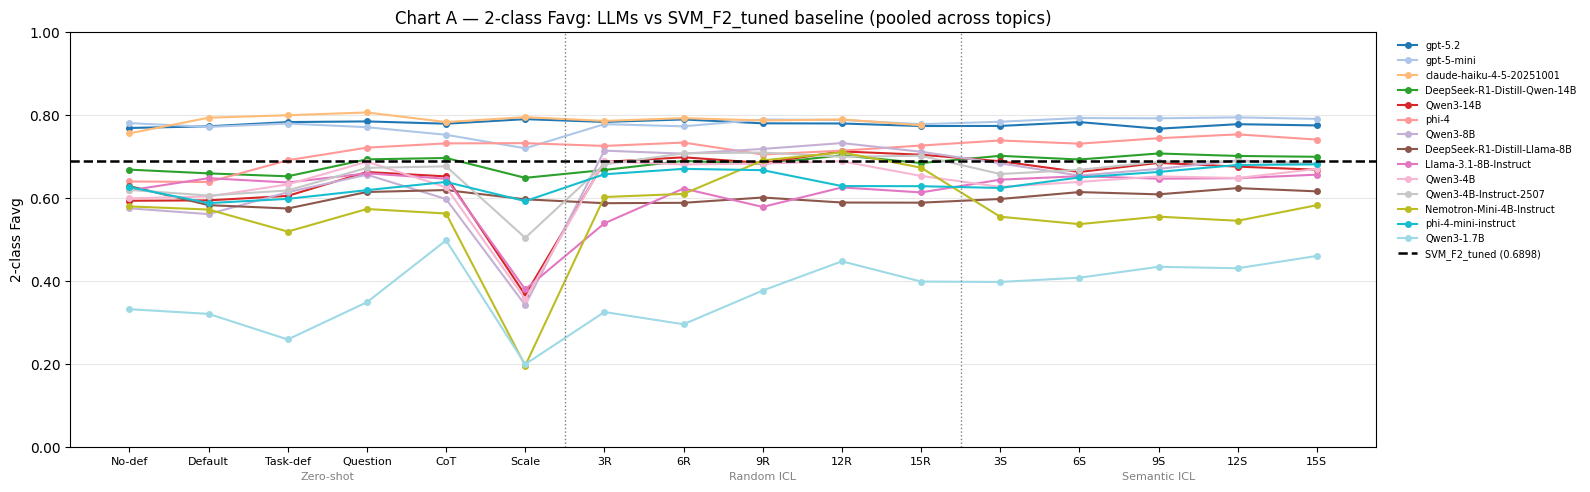

In [98]:
def plot_llm_vs_baseline(llm_df, metric_col, baselines, ylabel, title):
    """
    baselines: list of (value, label, linestyle, color) tuples.
    Each tuple draws one horizontal reference line.
    """
    available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
    x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]
    x_pos = list(range(len(available_prompts)))

    models = _ordered_models(llm_df)
    cmap = plt.cm.get_cmap("tab20", len(models))

    fig, ax = plt.subplots(figsize=(16, 5))

    for i, model in enumerate(models):
        mdf = llm_df[llm_df["model"] == model].set_index("prompt")
        y = [mdf.loc[p, metric_col] if p in mdf.index else float("nan") for p in available_prompts]
        short = model.split("/")[-1] if "/" in model else model
        ax.plot(x_pos, y, marker="o", linewidth=1.5, markersize=4,
                label=short, color=cmap(i))

    for val, lbl, ls, col in baselines:
        ax.axhline(val, color=col, linestyle=ls, linewidth=1.8, label=f"{lbl} ({val:.4f})")

    ax.set_ylim(0, 1)

    sep_pairs = [
        ("task_definition_scale", "few_shot_3"),
        ("few_shot_15",           "semantic_icl_3"),
    ]
    boundaries = [-0.5]
    for left, right in sep_pairs:
        if left in available_prompts and right in available_prompts:
            sx = (available_prompts.index(left) + available_prompts.index(right)) / 2
            boundaries.append(sx)
            ax.axvline(sx, color="grey", linestyle=":", linewidth=1)
    boundaries.append(len(available_prompts) - 0.5)

    group_labels = ["Zero-shot", "Random ICL", "Semantic ICL"]
    for i, lbl in enumerate(group_labels):
        if i < len(boundaries) - 1:
            mid = (boundaries[i] + boundaries[i+1]) / 2
            ax.text(mid, -0.08, lbl, ha="center", fontsize=8, color="grey",
                    transform=ax.get_xaxis_transform())

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, frameon=False)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Chart A: F2 metric, F2-tuned SVM baseline
plot_llm_vs_baseline(
    llm_df, "2class_favg",
    baselines=[
        (SVM_F2_TUNED_2CLASS, "SVM_F2_tuned", "--", "black"),
    ],
    ylabel="2-class Favg",
    title="Chart A — 2-class Favg: LLMs vs SVM_F2_tuned baseline (pooled across topics)",
)

## Step 11: Chart B — 3-class Macro F1 vs SVM_F3_tuned

Baseline = SVM_F3_tuned: C selected by 3-class Macro F1 — metric-matched, fair comparison for LLMs.
Compare Chart A vs Chart B to see whether models that beat the SVM on F2 also beat a properly-tuned SVM on F3.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5574/2901225699.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(models))


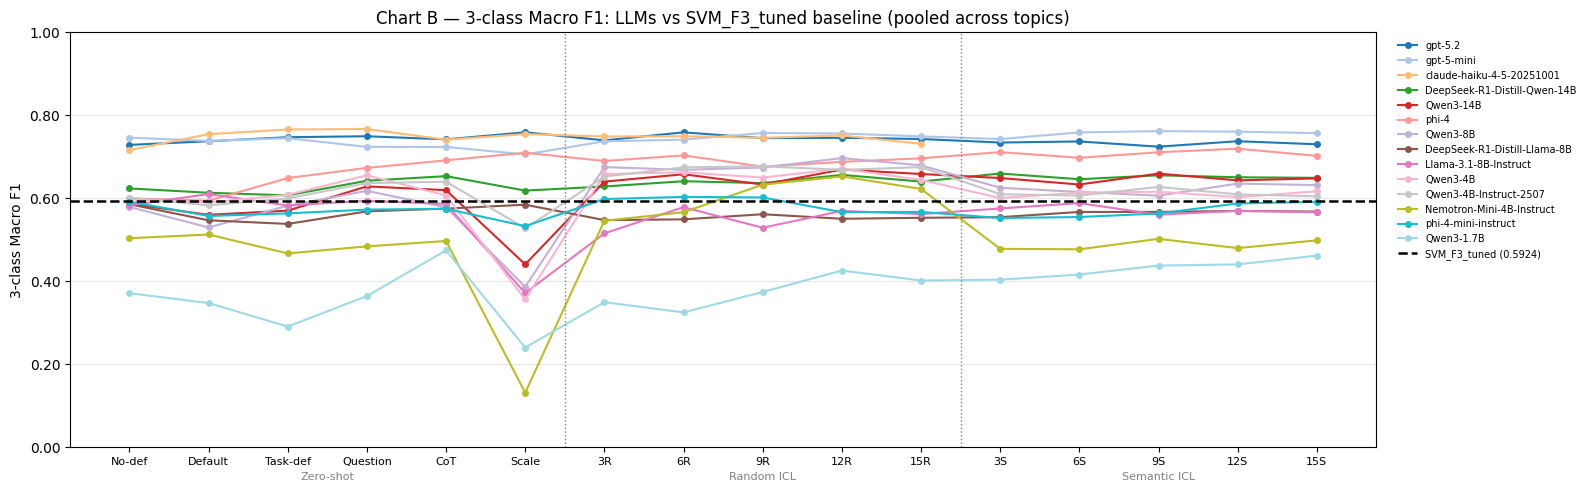

In [99]:
# Chart B: F3 metric, F3-tuned SVM baseline
plot_llm_vs_baseline(
    llm_df, "3class_macro_f1",
    baselines=[
        (SVM_F3_TUNED_3CLASS, "SVM_F3_tuned", "--", "black"),
    ],
    ylabel="3-class Macro F1",
    title="Chart B — 3-class Macro F1: LLMs vs SVM_F3_tuned baseline (pooled across topics)",
)

## Step 11b: Numerical Tables — 2-class Favg and 3-class Macro F1

**Table I** — per model summary: mean and best F2 / F3 across all prompts (SVM as reference).  
**Table II** — per model × prompt: F2 and F3 side by side, sorted by model then prompt order.

In [100]:
import pandas as pd

# ── Table I: per-model summary ──────────────────────────────────────────────
summary = (
    llm_df.groupby("model")
    .agg(
        mean_f2=("2class_favg",     "mean"),
        best_f2=("2class_favg",     "max"),
        mean_f3=("3class_macro_f1", "mean"),
        best_f3=("3class_macro_f1", "max"),
    )
    .reset_index()
)
summary["model_short"] = summary["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
summary = summary.sort_values("mean_f3", ascending=False).reset_index(drop=True)

hdr = f"{'Model':<35} {'Mean F2':>8} {'Best F2':>8} {'Mean F3':>8} {'Best F3':>8} {'F3-F2 (mean)':>13}"
sep = "─" * len(hdr)
print("=== Table I: Per-model summary — F2 and F3 across all prompts ===\n")
print(hdr)
print(sep)
print(f"{'SVM baseline':<35} {SVM_F2_TUNED_2CLASS:>8.4f} {SVM_F2_TUNED_2CLASS:>8.4f} "
      f"{SVM_F2_TUNED_3CLASS:>8.4f} {SVM_F2_TUNED_3CLASS:>8.4f} "
      f"{SVM_F2_TUNED_3CLASS - SVM_F2_TUNED_2CLASS:>+13.4f}")
print(sep)
for _, r in summary.iterrows():
    diff = r["mean_f3"] - r["mean_f2"]
    print(f"{r['model_short']:<35} {r['mean_f2']:>8.4f} {r['best_f2']:>8.4f} "
          f"{r['mean_f3']:>8.4f} {r['best_f3']:>8.4f} {diff:>+13.4f}")

# ── Table II: per model × prompt ────────────────────────────────────────────
detail = llm_df[["model", "prompt", "2class_favg", "3class_macro_f1"]].copy()
detail["model_short"] = detail["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
detail["prompt_rank"] = detail["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})
detail["prompt_label"] = detail["prompt"].map(PROMPT_LABELS_CHART)
detail = detail.sort_values(["mean_f3".replace("mean_f3","model_short"), "prompt_rank"],
                            key=lambda c: detail["model_short"] if c.name == "model_short" else c)

# re-sort cleanly
model_order = summary["model_short"].tolist()
detail["model_rank"] = detail["model_short"].map({m: i for i, m in enumerate(model_order)})
detail = detail.sort_values(["model_rank", "prompt_rank"]).reset_index(drop=True)

hdr2 = f"{'Model':<35} {'Prompt':<20} {'F2':>8} {'F3':>8} {'F3−F2':>8}"
sep2  = "─" * len(hdr2)
print(f"\n\n=== Table II: Per model × prompt — F2 and F3 ===\n")
print(hdr2)
print(sep2)
prev_model = None
for _, r in detail.iterrows():
    if prev_model and r["model_short"] != prev_model:
        print()
    diff = r["3class_macro_f1"] - r["2class_favg"]
    print(f"{r['model_short']:<35} {r['prompt_label']:<20} "
          f"{r['2class_favg']:>8.4f} {r['3class_macro_f1']:>8.4f} {diff:>+8.4f}")
    prev_model = r["model_short"]

=== Table I: Per-model summary — F2 and F3 across all prompts ===

Model                                Mean F2  Best F2  Mean F3  Best F3  F3-F2 (mean)
─────────────────────────────────────────────────────────────────────────────────────
SVM baseline                          0.6898   0.6898   0.5921   0.5921       -0.0977
─────────────────────────────────────────────────────────────────────────────────────
claude-haiku-4-5-20251001             0.7873   0.8060   0.7469   0.7660       -0.0404
gpt-5-mini                            0.7768   0.7941   0.7431   0.7610       -0.0337
gpt-5.2                               0.7785   0.7898   0.7403   0.7581       -0.0382
phi-4                                 0.7164   0.7531   0.6811   0.7186       -0.0353
DeepSeek-R1-Distill-Qwen-14B          0.6839   0.7070   0.6379   0.6588       -0.0460
Qwen3-4B-Instruct-2507                0.6610   0.7094   0.6237   0.6761       -0.0373
Qwen3-14B                             0.6459   0.7120   0.6177   0.6682  

## Step 12: Per-class Precision / Recall / F1 breakdown

3 × 3 grid: **rows** = class (FAVOR, AGAINST, NONE), **columns** = metric (Precision, Recall, F1).  
Each panel shows all LLMs as lines across prompting methods, with the SVM baseline as a dotted horizontal line.  
This reveals *why* 2-class and 3-class scores diverge: NONE has very different P/R behaviour across model families.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5574/3735729566.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", len(models))


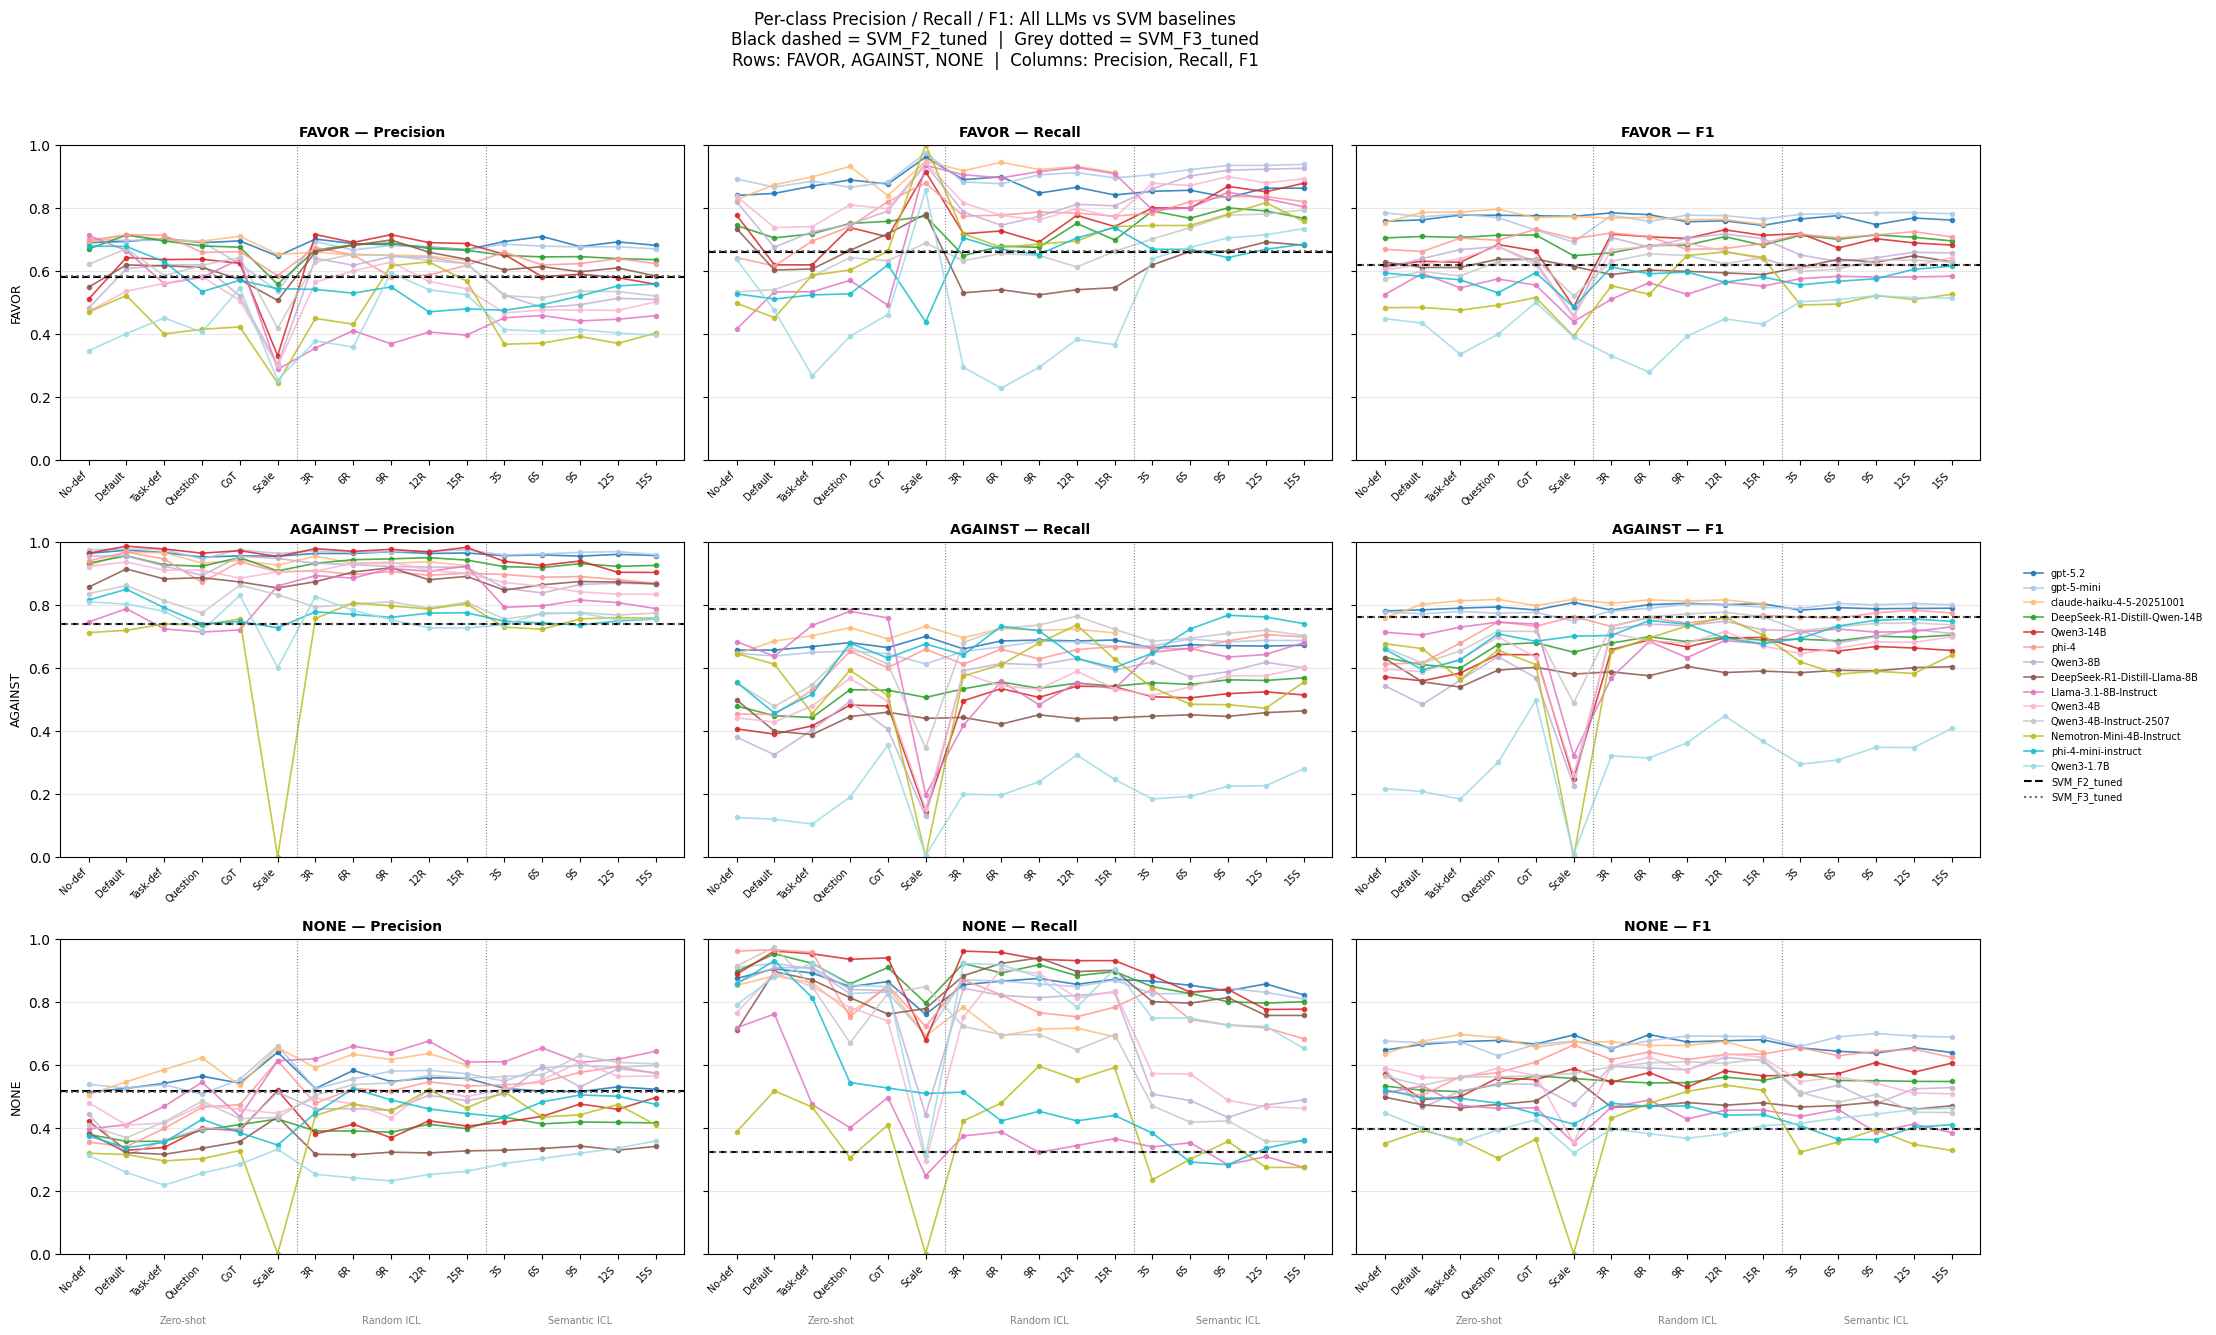

In [101]:
CLASSES  = ["FAVOR", "AGAINST", "NONE"]
METRICS  = [("p", "Precision"), ("r", "Recall"), ("f", "F1")]

available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_pos    = list(range(len(available_prompts)))
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", len(models))

sep_pairs = [
    ("task_definition_scale", "few_shot_3"),
    ("few_shot_15",           "semantic_icl_3"),
]

fig, axes = plt.subplots(3, 3, figsize=(20, 13), sharey="row")

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (metric_key, metric_label) in enumerate(METRICS):
        ax = axes[row_idx][col_idx]
        col_name = f"{metric_key}_{cls.lower()}"

        for i, model in enumerate(models):
            mdf  = llm_df[llm_df["model"] == model].set_index("prompt")
            y    = [mdf.loc[p, col_name] if p in mdf.index else float("nan") for p in available_prompts]
            short = model.split("/")[-1] if "/" in model else model
            ax.plot(x_pos, y, marker="o", linewidth=1.2, markersize=3,
                    label=short, color=cmap(i), alpha=0.85)

        # SVM_F2_tuned baseline (black dashed)
        ax.axhline(SVM_F2_PER_CLASS[cls][metric_key], color="black",   linestyle="--", linewidth=1.5)
        # SVM_F3_tuned baseline (grey dotted)
        ax.axhline(SVM_F3_PER_CLASS[cls][metric_key], color="dimgrey", linestyle=":",  linewidth=1.5)

        for left, right in sep_pairs:
            if left in available_prompts and right in available_prompts:
                sx = (available_prompts.index(left) + available_prompts.index(right)) / 2
                ax.axvline(sx, color="grey", linestyle=":", linewidth=0.8)

        ax.set_ylim(0, 1)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{cls} — {metric_label}", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9)

# shared legend
import matplotlib.lines as mlines
handles, leg_labels = axes[0][0].get_legend_handles_labels()
handles += [
    mlines.Line2D([], [], color="black",   linestyle="--", linewidth=1.5, label="SVM_F2_tuned"),
    mlines.Line2D([], [], color="dimgrey", linestyle=":",  linewidth=1.5, label="SVM_F3_tuned"),
]
leg_labels += ["SVM_F2_tuned", "SVM_F3_tuned"]
fig.legend(handles, leg_labels, bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=7, frameon=False)

# group labels
group_names = ["Zero-shot", "Random ICL", "Semantic ICL"]
boundaries  = [-0.5]
for left, right in sep_pairs:
    if left in available_prompts and right in available_prompts:
        boundaries.append((available_prompts.index(left) + available_prompts.index(right)) / 2)
boundaries.append(len(available_prompts) - 0.5)
for col_idx in range(3):
    ax = axes[2][col_idx]
    for gi, glbl in enumerate(group_names):
        if gi < len(boundaries) - 1:
            mid = (boundaries[gi] + boundaries[gi + 1]) / 2
            ax.text(mid, -0.22, glbl, ha="center", fontsize=7, color="grey",
                    transform=ax.get_xaxis_transform())

fig.suptitle(
    "Per-class Precision / Recall / F1: All LLMs vs SVM baselines\n"
    "Black dashed = SVM_F2_tuned  |  Grey dotted = SVM_F3_tuned\n"
    "Rows: FAVOR, AGAINST, NONE  |  Columns: Precision, Recall, F1",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 12b: Per-class F1 — Model Comparison (mean ± std across prompts)

Three panels (FAVOR / AGAINST / NONE).  
Each dot = mean class F1 across all prompts for that model. Error bar = std across prompts.  
Dashed line = SVM class-specific F1.  
Answers: which models consistently beat the SVM on each class?

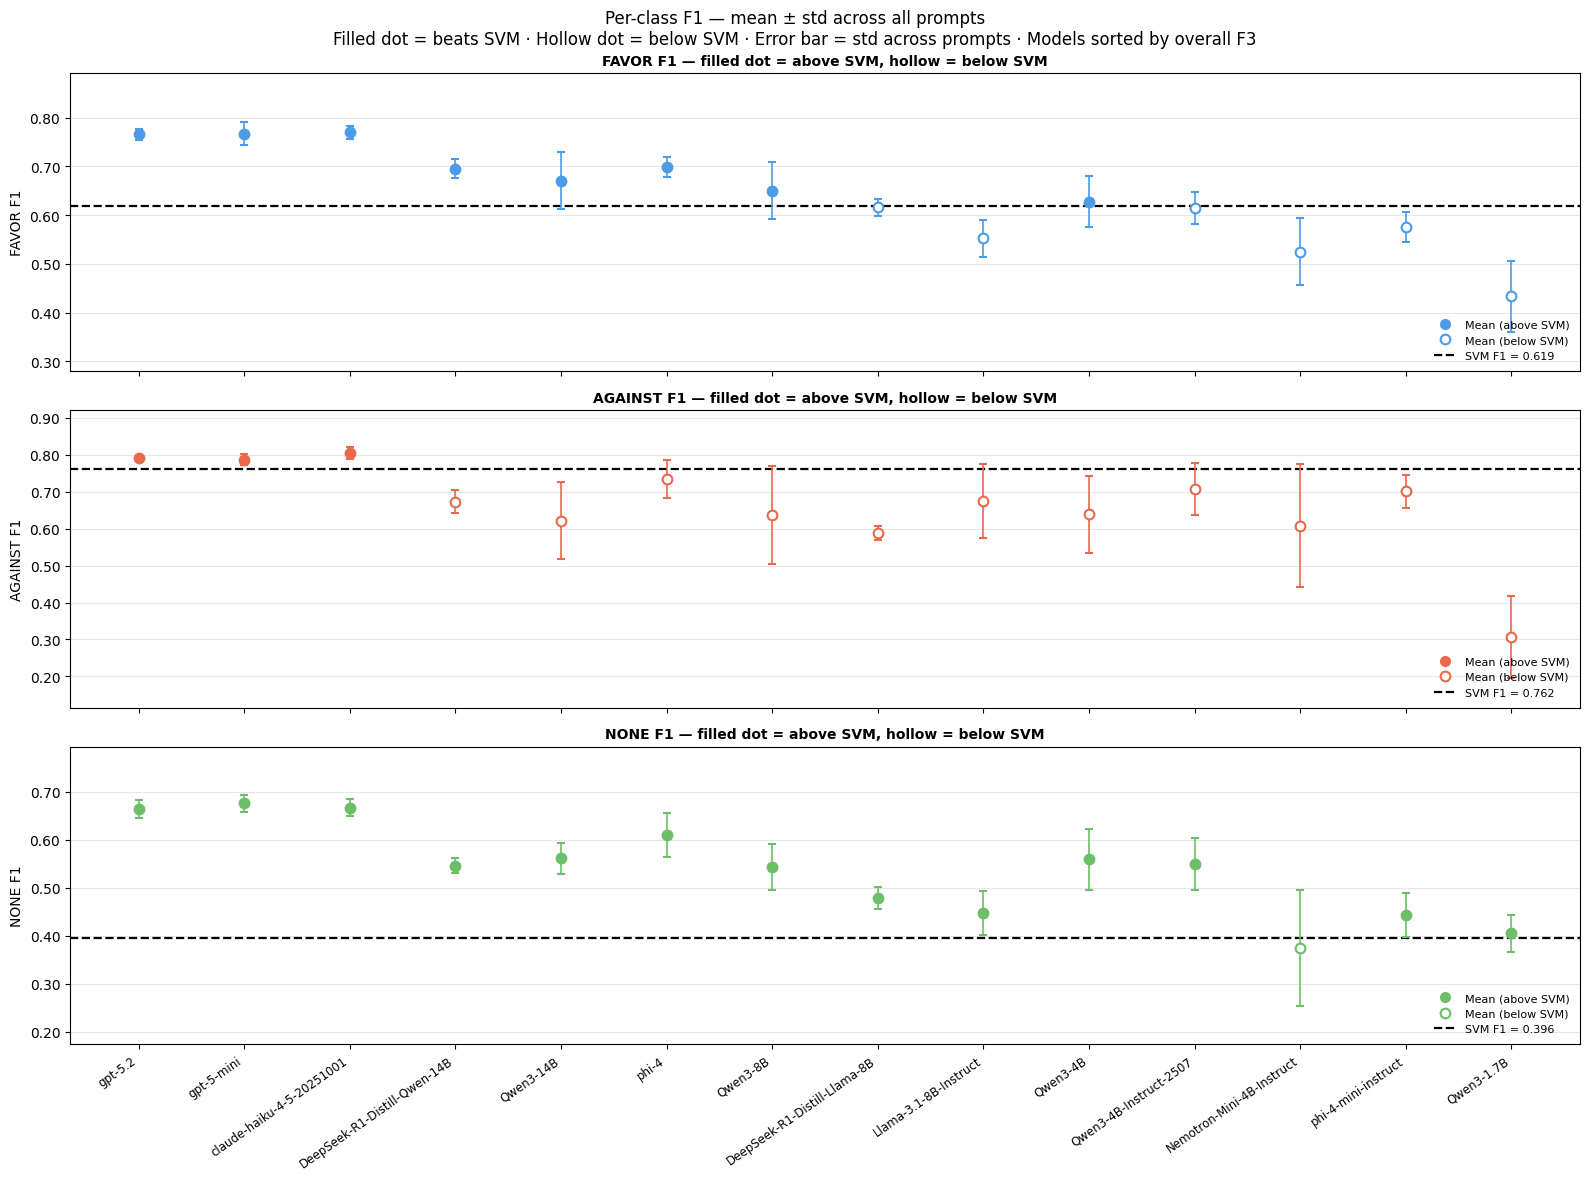

In [102]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import numpy as np

CLASS_COLS  = {"FAVOR": "f_favor", "AGAINST": "f_against", "NONE": "f_none"}
CLASS_COLOR = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C",   "NONE": "#6DBF67"}
SVM_CLS_F1  = {
    "FAVOR":   SVM_F3_PER_CLASS["FAVOR"]["f"],
    "AGAINST": SVM_F3_PER_CLASS["AGAINST"]["f"],
    "NONE":    SVM_F3_PER_CLASS["NONE"]["f"],
}

# model order: best overall mean F3 first
model_order = _ordered_models(llm_df)
model_labels = [m.split("/")[-1] if "/" in m else m for m in model_order]
x = np.arange(len(model_order))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax      = axes[row_idx]
    col     = CLASS_COLS[cls]
    color   = CLASS_COLOR[cls]
    svm_f1  = SVM_CLS_F1[cls]

    # per-model mean ± std
    means, stds = [], []
    for model in model_order:
        vals = llm_df[llm_df["model"] == model][col].values
        means.append(vals.mean())
        stds.append(vals.std())
    means = np.array(means)
    stds  = np.array(stds)

    # colour dots: above SVM = filled, below = hollow
    for i, (m, s) in enumerate(zip(means, stds)):
        above = m >= svm_f1
        ax.errorbar(x[i], m, yerr=s, fmt="o", markersize=7,
                    color=color if above else "white",
                    markeredgecolor=color, markeredgewidth=1.5,
                    ecolor=color, elinewidth=1.2, capsize=3, zorder=3)

    # SVM reference
    ax.axhline(svm_f1, color="black", linestyle="--", linewidth=1.6,
               label=f"SVM {cls} F1 = {svm_f1:.3f}")

    ax.set_ylabel(f"{cls} F1", fontsize=10)
    ax.set_ylim(max(0, min(means - stds) - 0.08), min(1, max(means + stds) + 0.1))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{cls} F1 — filled dot = above SVM, hollow = below SVM", fontsize=10, fontweight="bold")

    legend_handles = [
        mlines.Line2D([], [], marker="o", color=color, markersize=7,
                      linestyle="None", label="Mean (above SVM)"),
        mlines.Line2D([], [], marker="o", color="white", markersize=7,
                      markeredgecolor=color, markeredgewidth=1.5,
                      linestyle="None", label="Mean (below SVM)"),
        mlines.Line2D([], [], color="black", linestyle="--", linewidth=1.6,
                      label=f"SVM F1 = {svm_f1:.3f}"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, frameon=False, loc="lower right")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(model_labels, rotation=35, ha="right", fontsize=8.5)

fig.suptitle(
    "Per-class F1 — mean ± std across all prompts\n"
    "Filled dot = beats SVM · Hollow dot = below SVM · Error bar = std across prompts · Models sorted by overall F3",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 13: Precision vs Recall Scatter — per class, all model×prompt points

One panel per class (FAVOR, AGAINST, NONE). Each dot = one model × prompt combination, coloured by model.
SVM baselines plotted as large stars.
Grey curves = F1 iso-contours (F1 = 0.2, 0.4, 0.6, 0.8).
Diagonal dashed line = P = R.

Key story to look for:
- **NONE panel**: SVM sits high-P / low-R (conservative); LLMs scatter toward low-P / high-R (over-predict NONE)
- **AGAINST panel**: most LLMs match or beat SVM; tight cluster expected
- **FAVOR panel**: SVM has low P; LLMs spread wide

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5574/1863010078.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap("tab20", len(models))


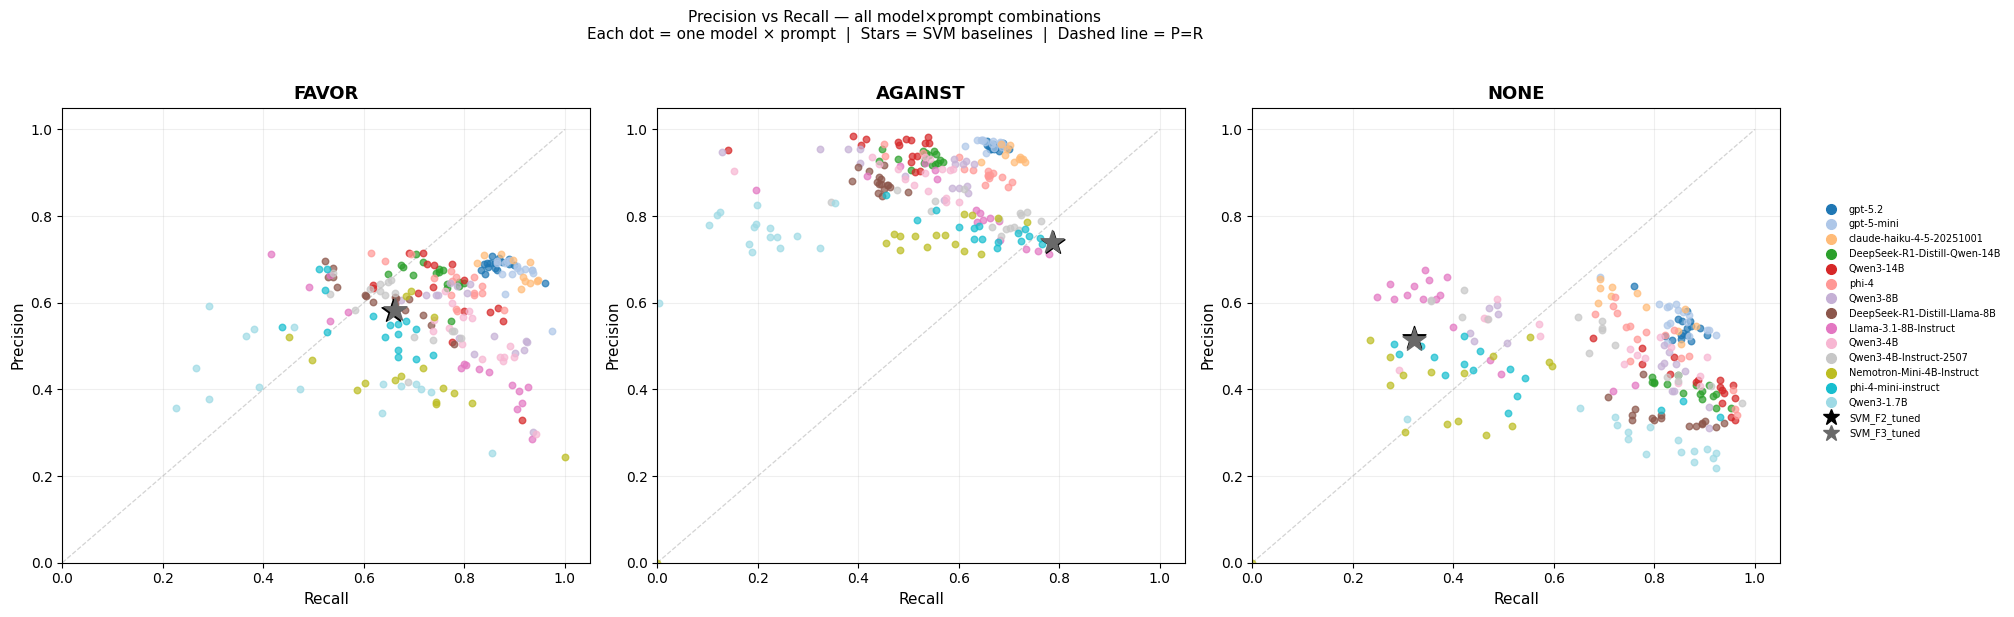

In [103]:
import matplotlib.lines as mlines

CLASSES = ["FAVOR", "AGAINST", "NONE"]
models  = _ordered_models(llm_df)
cmap    = plt.cm.get_cmap("tab20", len(models))
model_color = {m: cmap(i) for i, m in enumerate(models)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col_idx, cls in enumerate(CLASSES):
    ax = axes[col_idx]
    p_col = f"p_{cls.lower()}"
    r_col = f"r_{cls.lower()}"

    # P = R diagonal
    ax.plot([0, 1], [0, 1], color="lightgrey", linestyle="--", linewidth=0.9, zorder=0)

    # LLM scatter — x=Recall, y=Precision
    for model in models:
        mdf = llm_df[llm_df["model"] == model]
        short = model.split("/")[-1] if "/" in model else model
        ax.scatter(mdf[r_col], mdf[p_col],
                   color=model_color[model], s=22, alpha=0.7, zorder=2, label=short)

    # SVM baselines as large stars
    ax.scatter(SVM_F2_PER_CLASS[cls]["r"], SVM_F2_PER_CLASS[cls]["p"],
               marker="*", s=300, color="black",   zorder=5, label="SVM_F2_tuned")
    ax.scatter(SVM_F3_PER_CLASS[cls]["r"], SVM_F3_PER_CLASS[cls]["p"],
               marker="*", s=300, color="dimgrey", zorder=5, label="SVM_F3_tuned")

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall",    fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(cls, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.2)

# Shared legend
handles = [mlines.Line2D([],[], marker="o", linestyle="None",
                          color=model_color[m], markersize=7,
                          label=m.split("/")[-1] if "/" in m else m)
           for m in models]
handles += [
    mlines.Line2D([],[], marker="*", linestyle="None", color="black",   markersize=12, label="SVM_F2_tuned"),
    mlines.Line2D([],[], marker="*", linestyle="None", color="dimgrey", markersize=12, label="SVM_F3_tuned"),
]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc="center left",
           fontsize=7, frameon=False)

fig.suptitle(
    "Precision vs Recall — all model×prompt combinations\n"
    "Each dot = one model × prompt  |  Stars = SVM baselines  |  Dashed line = P=R",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 16: Predicted vs Gold Distribution — per class, per model across all prompts

Three panels (FAVOR / AGAINST / NONE). Each dot = one model × prompt predicted %.  
Diamond = mean across prompts. Red dotted line = gold % in the test set.  
Shows directly whether models systematically over- or under-predict each class.

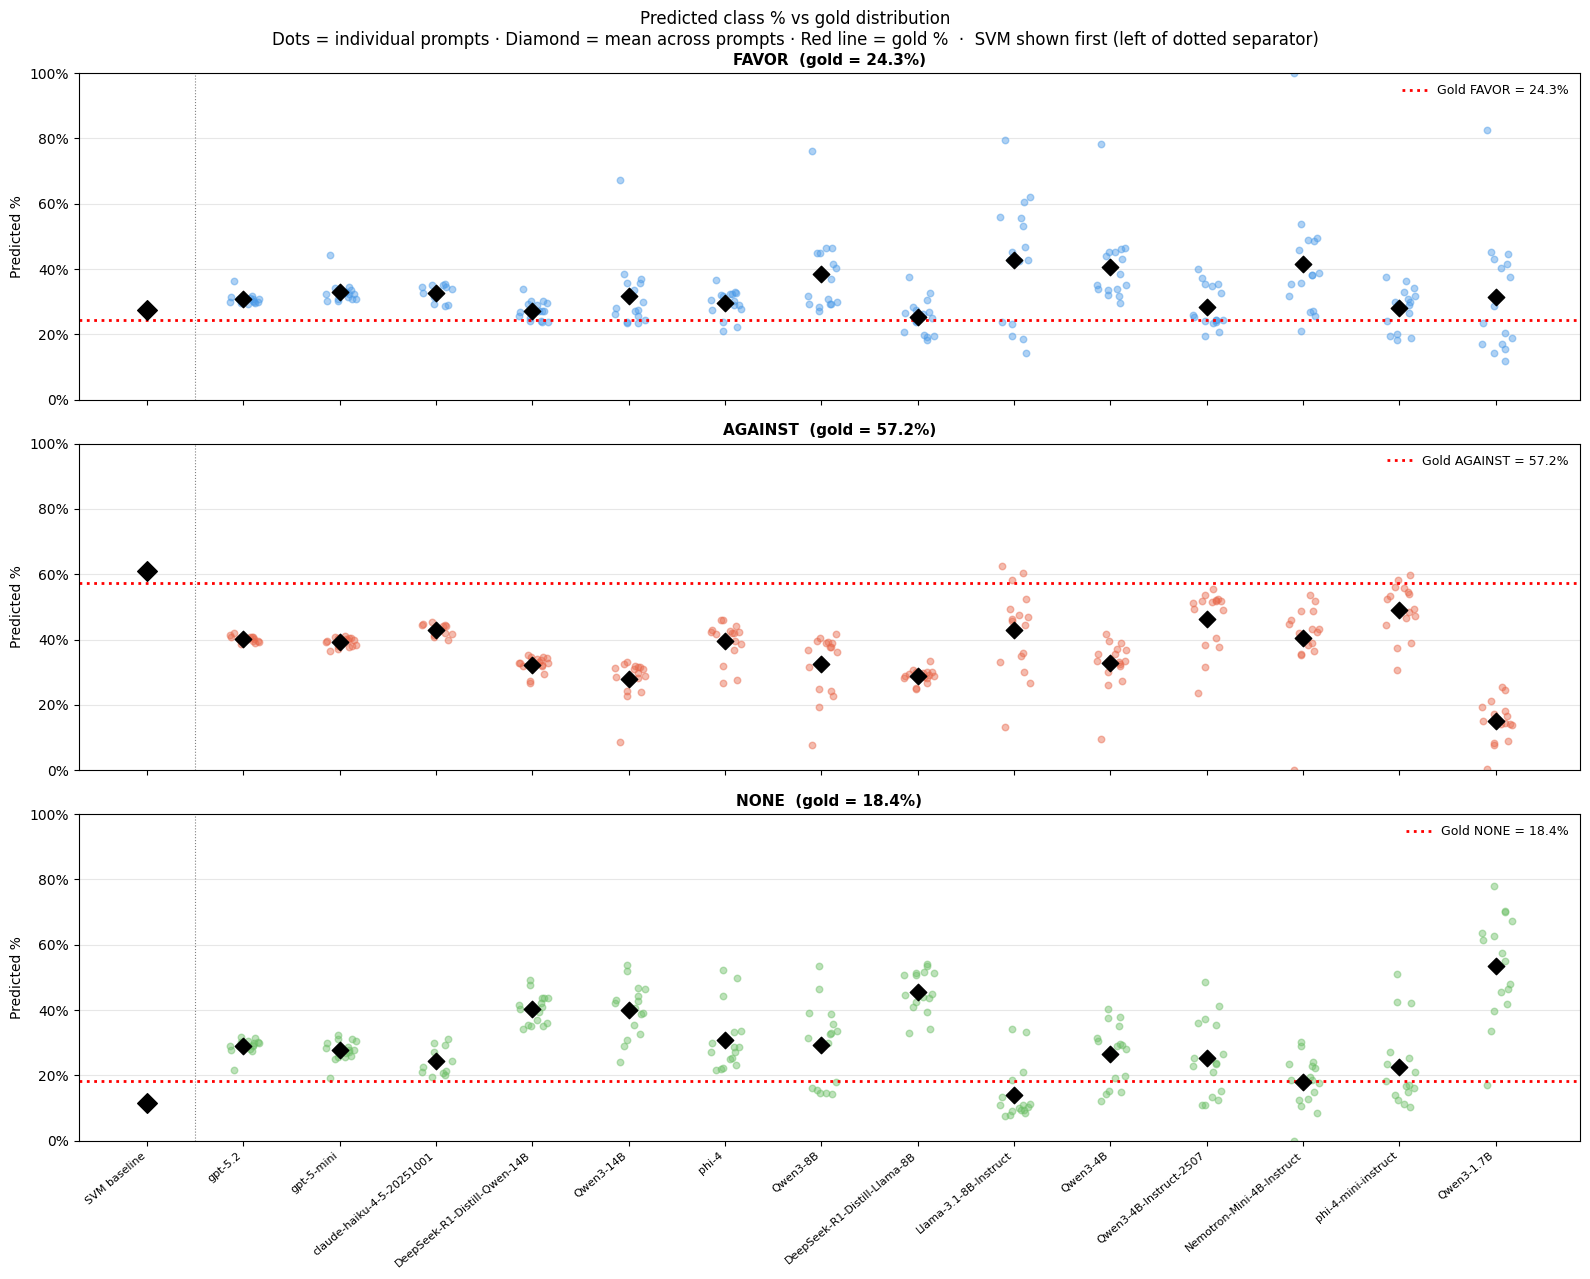

In [104]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

GOLD = {"FAVOR": 304/1249, "AGAINST": 715/1249, "NONE": 230/1249}
CLASS_COLS = {"FAVOR": "pred_favor", "AGAINST": "pred_against", "NONE": "pred_none"}
CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}
PREFIX = "GenAIStanceOneShot_1249_semeval2016_task6_testdata_gold_"

# ── Recompute dist_df (predicted distribution per model×prompt) ─────────────
dist_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_1249"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem  = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["original_stance"].isin(["FAVOR","AGAINST","NONE"])].copy()
    df["predicted_stance"] = df["predicted_stance"].astype(str).str.upper().str.strip()
    df = df[df["predicted_stance"].isin(["FAVOR","AGAINST","NONE"])]
    if len(df) < 100:
        continue
    vc = df["predicted_stance"].value_counts(normalize=True)
    dist_rows.append({
        "model":        model,
        "prompt":       prompt,
        "pred_favor":   vc.get("FAVOR",   0),
        "pred_against": vc.get("AGAINST", 0),
        "pred_none":    vc.get("NONE",    0),
    })

dist_df = pd.DataFrame(dist_rows)

# ── SVM predicted distribution ─────────────────────────────────────────────
_svm_preds = pd.Series([r["pred"] for r in all_preds_f3])
svm_dist   = _svm_preds.value_counts(normalize=True)
SVM_PRED = {
    "FAVOR":   svm_dist.get("FAVOR",   0),
    "AGAINST": svm_dist.get("AGAINST", 0),
    "NONE":    svm_dist.get("NONE",    0),
}

dist_df["model_short"] = dist_df["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
llm_models_sorted = _ordered_models(dist_df, "model_short")
all_models = ["SVM baseline"] + llm_models_sorted
x = np.arange(len(all_models))
model_idx = {m: i for i, m in enumerate(all_models)}

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax = axes[row_idx]
    col = CLASS_COLS[cls]
    gold_pct = GOLD[cls]
    color = CLASS_COLORS[cls]

    # SVM — single diamond
    xi_svm = model_idx["SVM baseline"]
    ax.scatter(xi_svm, SVM_PRED[cls], marker="D", s=100, color="black", zorder=5)
    ax.axvline(xi_svm + 0.5, color="grey", linestyle=":", linewidth=0.8)

    # LLMs — dots per prompt + mean diamond
    for model in llm_models_sorted:
        mdf = dist_df[dist_df["model_short"] == model]
        xi = model_idx[model]
        jitter = (np.random.default_rng(42).random(len(mdf)) - 0.5) * 0.35
        ax.scatter(xi + jitter, mdf[col], alpha=0.45, s=22, color=color, zorder=2)
        ax.scatter(xi, mdf[col].mean(), marker="D", s=70, color="black", zorder=4)

    ax.axhline(gold_pct, color="red", linestyle=":", linewidth=2,
               label=f"Gold {cls} = {gold_pct:.1%}")

    ax.set_ylabel("Predicted %", fontsize=10)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(f"{cls}  (gold = {gold_pct:.1%})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(all_models, rotation=40, ha="right", fontsize=8)

fig.suptitle(
    "Predicted class % vs gold distribution\n"
    "Dots = individual prompts · Diamond = mean across prompts · Red line = gold %  ·  SVM shown first (left of dotted separator)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 17: Confusion Transition Analysis — Key Misclassifications

Six transitions of interest (off-diagonal only):

| Transition | Story |
|---|---|
| AGAINST → NONE | True AGAINST softened to neutral |
| AGAINST → FAVOR | True AGAINST flipped to positive |
| FAVOR → AGAINST | True FAVOR pushed to negative |
| FAVOR → NONE | True FAVOR softened to neutral |
| NONE → FAVOR | True NONE over-labelled positive |
| NONE → AGAINST | True NONE over-labelled negative |

**Table A** — per model, averaged across all prompts.  
**Table B** — per model × prompt (full detail).  
Each heatmap accompanies its table.

=== Table A: Confusion Transitions — per model (mean across all prompts) ===
Model                                   FAVOR→FAVOR   FAVOR→AGAINST      FAVOR→NONE   AGAINST→FAVOR AGAINST→AGAINST    AGAINST→NONE      NONE→FAVOR    NONE→AGAINST       NONE→NONE
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5.2                                      86.7%            1.7%           11.5%           14.3%           67.3%           18.4%            8.0%            6.4%           85.6% 
gpt-5-mini                                   90.4%            1.1%            8.6%           16.2%           66.3%           17.6%            9.8%            5.7%           84.5% 
claude-haiku-4-5-20251001                    90.3%            2.7%            7.0%           14.9%           70.5%           14.6%           12.1%           10.7%           77.2% 
DeepSeek-R1-Distill-Qwe

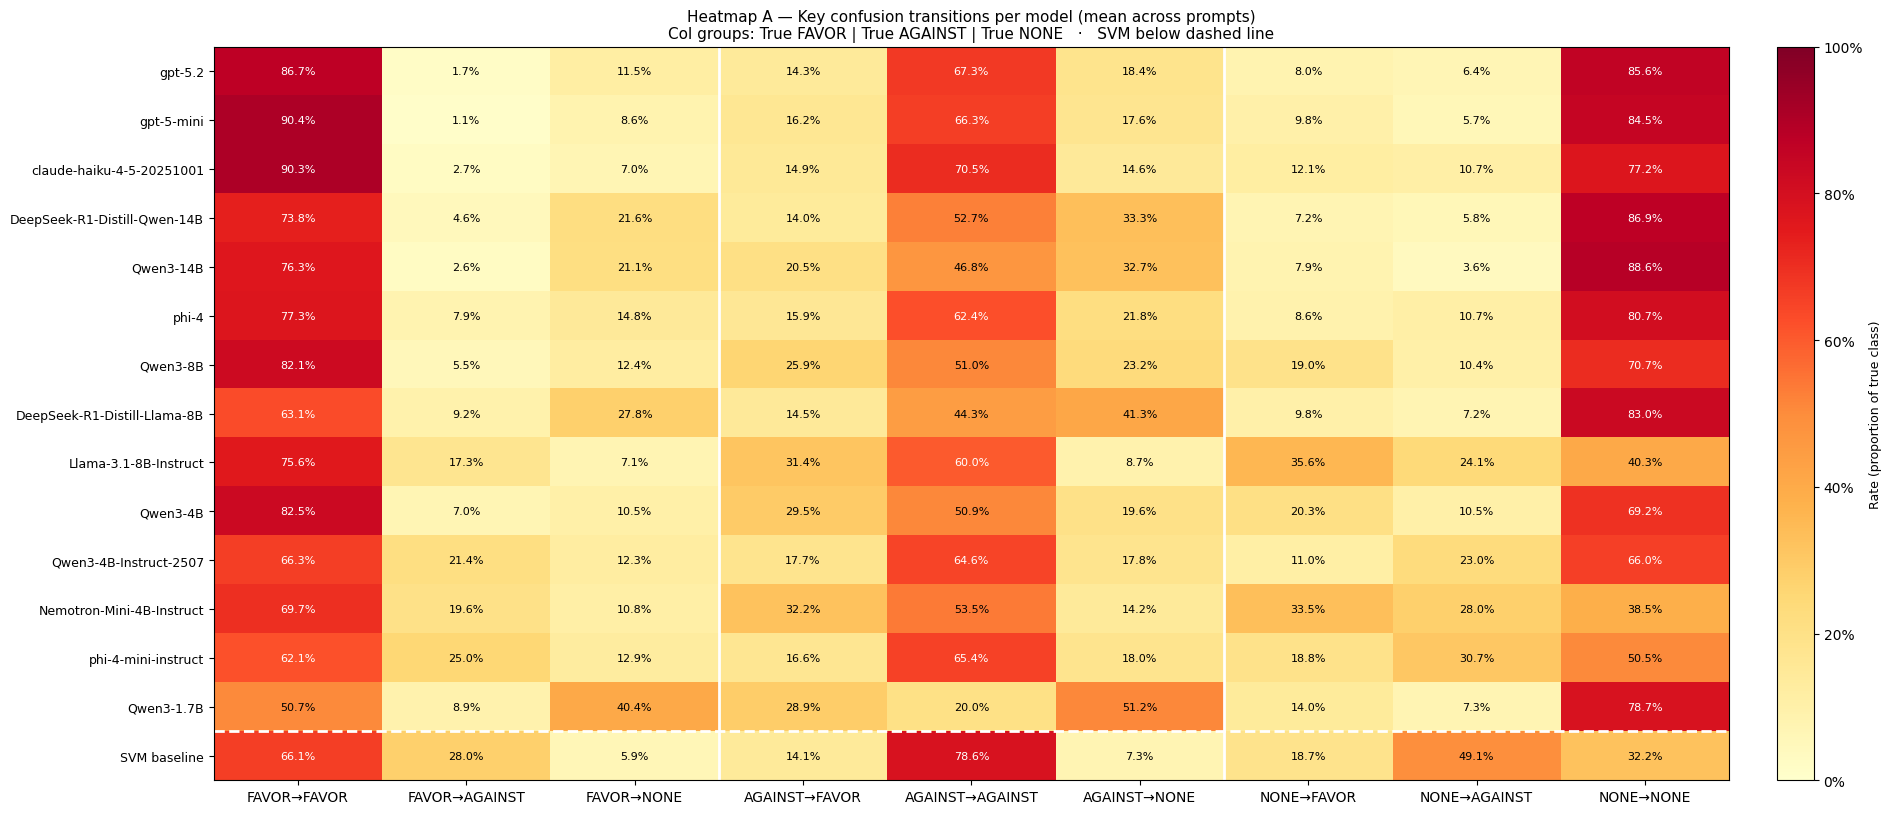


=== Table B: Confusion Transitions — per model × prompt ===
Model · Prompt                                       FAVOR→FAVOR   FAVOR→AGAINST      FAVOR→NONE   AGAINST→FAVOR AGAINST→AGAINST    AGAINST→NONE      NONE→FAVOR    NONE→AGAINST       NONE→NONE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DeepSeek-R1-Distill-Llama-8B · No-def                     73.4%           10.9%           15.8%           20.1%           49.8%           30.1%           17.4%           11.7%           70.9% 
DeepSeek-R1-Distill-Llama-8B · Default                    60.2%            5.9%           33.9%           13.7%           39.9%           46.4%            6.5%            3.9%           89.6% 
DeepSeek-R1-Distill-Llama-8B · Task-def                   60.5%            7.9%           31.6%           13.8%           38.8%           47.5%            7.4%        

In [105]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import os

CLASSES = ["FAVOR", "AGAINST", "NONE"]
KEY_TRANS = [
    "FAVOR→FAVOR",   "FAVOR→AGAINST",   "FAVOR→NONE",
    "AGAINST→FAVOR", "AGAINST→AGAINST", "AGAINST→NONE",
    "NONE→FAVOR",    "NONE→AGAINST",    "NONE→NONE",
]
PREFIX = "GenAIStanceOneShot_1249_semeval2016_task6_testdata_gold_"

# ── Recompute per model×prompt confusion matrices ──────────────────────────
cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_1249"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].astype(str).str.upper().str.strip()
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue
    yt, yp = df["original_stance"].tolist(), df["predicted_stance"].tolist()
    cm = confusion_matrix(yt, yp, labels=CLASSES).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    row = {"model": model, "prompt": prompt,
           "model_short": model.split("/")[-1] if "/" in model else model}
    for r_idx, tc in enumerate(CLASSES):
        for c_idx, pc in enumerate(CLASSES):
            row[f"{tc}→{pc}"] = cm_norm[r_idx, c_idx]
    cm_rows.append(row)

cm_df = pd.DataFrame(cm_rows)
cm_df["prompt_rank"] = cm_df["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})

# SVM reference row
yt_svm = [r["true"] for r in all_preds_f3]
yp_svm = [r["pred"] for r in all_preds_f3]
cm_svm_norm = confusion_matrix(yt_svm, yp_svm, labels=CLASSES).astype(float)
cm_svm_norm /= cm_svm_norm.sum(axis=1, keepdims=True)
svm_row = {"model_short": "SVM baseline"}
for r_idx, tc in enumerate(CLASSES):
    for c_idx, pc in enumerate(CLASSES):
        svm_row[f"{tc}→{pc}"] = cm_svm_norm[r_idx, c_idx]

# ═══════════════════════════════════════════════════════════════════
# TABLE A + HEATMAP A — per model (mean across prompts)
# ═══════════════════════════════════════════════════════════════════
mean_cm = cm_df.groupby("model_short")[KEY_TRANS].mean().reset_index()
llm_mean = mean_cm.set_index("model_short").reindex([m for m in MODEL_ORDER if m in cm_df["model_short"].unique()])
table_a = pd.concat([llm_mean, pd.DataFrame([svm_row]).set_index("model_short")])

print("=== Table A: Confusion Transitions — per model (mean across all prompts) ===")
print(f"{'Model':<35}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (35 + 16 * len(KEY_TRANS)))
for model, row in table_a.iterrows():
    print(f"{model:<35}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))

fig, ax = plt.subplots(figsize=(19, max(5, len(table_a) * 0.55)))
data_a = table_a[KEY_TRANS].values
im = ax.imshow(data_a, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)

ax.set_xticks(range(len(KEY_TRANS)))
ax.set_xticklabels(KEY_TRANS, fontsize=10)
ax.set_yticks(range(len(table_a)))
ax.set_yticklabels(table_a.index, fontsize=9)

# column group separators (AGAINST | FAVOR | NONE errors)
for sep in [2.5, 5.5]:
    ax.axvline(sep, color="white", linewidth=2)

# SVM separator (last row)
ax.axhline(len(table_a) - 1.5, color="white", linewidth=2, linestyle="--")

for i in range(data_a.shape[0]):
    for j in range(data_a.shape[1]):
        ax.text(j, i, f"{data_a[i,j]:.1%}", ha="center", va="center", fontsize=8,
                color="white" if data_a[i,j] > 0.55 else "black")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label("Rate (proportion of true class)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(
    "Heatmap A — Key confusion transitions per model (mean across prompts)\n"
    "Col groups: True FAVOR | True AGAINST | True NONE   ·   SVM below dashed line",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TABLE B + HEATMAP B — per model × prompt
# ═══════════════════════════════════════════════════════════════════
cm_sorted = cm_df.sort_values(["model_short", "prompt_rank"])
cm_sorted["row_label"] = (
    cm_sorted["model_short"] + " · " +
    cm_sorted["prompt"].map(PROMPT_LABELS_CHART)
)

print("\n=== Table B: Confusion Transitions — per model × prompt ===")
print(f"{'Model · Prompt':<48}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (48 + 16 * len(KEY_TRANS)))
prev = None
for _, row in cm_sorted.iterrows():
    if prev and row["model_short"] != prev:
        print()
    print(f"{row['row_label']:<48}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))
    prev = row["model_short"]





## Step 18: Model Ranking Table (F3)

Per-model summary across all prompts: mean, best, std F3 + mean per-class F1.  
SVM_F2_tuned included as reference. Sorted by mean F3 descending.

=== Model Ranking Table — F3 (sorted by mean F3 across all prompts) ===

Model                                Mean F3  Best F3   Std F3   F1 FAV   F1 AGN   F1 NON
─────────────────────────────────────────────────────────────────────────────────────────
claude-haiku-4-5-20251001             0.7469   0.7660   0.0146   0.7697   0.8048   0.6662
gpt-5-mini                            0.7431   0.7610   0.0157   0.7674   0.7863   0.6757
gpt-5.2                               0.7403   0.7581   0.0098   0.7655   0.7915   0.6638
phi-4                                 0.6811   0.7186   0.0375   0.6986   0.7342   0.6104
DeepSeek-R1-Distill-Qwen-14B          0.6379   0.6588   0.0162   0.6952   0.6726   0.5460
Qwen3-4B-Instruct-2507                0.6237   0.6761   0.0403   0.6145   0.7075   0.5491
Qwen3-14B                             0.6177   0.6682   0.0573   0.6707   0.6212   0.5611
Qwen3-8B                              0.6104   0.6959   0.0751   0.6505   0.6377   0.5431
Qwen3-4B                   

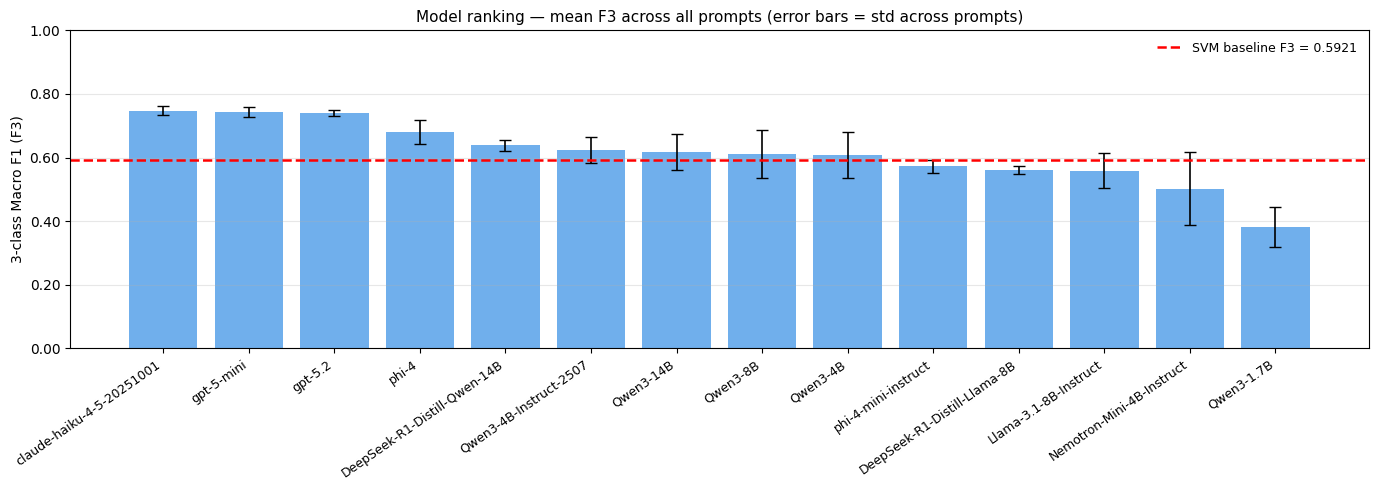

In [106]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Build per-model summary from llm_df ────────────────────────────────────
ranking = (
    llm_df.groupby("model")
    .agg(
        mean_f3   =("3class_macro_f1", "mean"),
        best_f3   =("3class_macro_f1", "max"),
        std_f3    =("3class_macro_f1", "std"),
        mean_f1_favor   =("f_favor",   "mean"),
        mean_f1_against =("f_against", "mean"),
        mean_f1_none    =("f_none",    "mean"),
    )
    .reset_index()
)
ranking["model_short"] = ranking["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
ranking = ranking.sort_values("mean_f3", ascending=False).reset_index(drop=True)

# SVM reference row
svm_ref = pd.DataFrame([{
    "model_short": "SVM baseline",
    "mean_f3": SVM_F2_TUNED_3CLASS,
    "best_f3": SVM_F2_TUNED_3CLASS,
    "std_f3":  0.0,
    "mean_f1_favor":   SVM_F2_PER_CLASS["FAVOR"]["f"],
    "mean_f1_against": SVM_F2_PER_CLASS["AGAINST"]["f"],
    "mean_f1_none":    SVM_F2_PER_CLASS["NONE"]["f"],
}])

# ── Print table ─────────────────────────────────────────────────────────────
header = f"{'Model':<35} {'Mean F3':>8} {'Best F3':>8} {'Std F3':>8} {'F1 FAV':>8} {'F1 AGN':>8} {'F1 NON':>8}"
sep    = "─" * len(header)
print("=== Model Ranking Table — F3 (sorted by mean F3 across all prompts) ===\n")
print(header)
print(sep)
for _, row in ranking.iterrows():
    print(f"{row['model_short']:<35} {row['mean_f3']:>8.4f} {row['best_f3']:>8.4f} {row['std_f3']:>8.4f} "
          f"{row['mean_f1_favor']:>8.4f} {row['mean_f1_against']:>8.4f} {row['mean_f1_none']:>8.4f}")
print(sep)
svm = svm_ref.iloc[0]
print(f"{'SVM baseline (reference)':<35} {svm['mean_f3']:>8.4f} {svm['best_f3']:>8.4f} {svm['std_f3']:>8.4f} "
      f"{svm['mean_f1_favor']:>8.4f} {svm['mean_f1_against']:>8.4f} {svm['mean_f1_none']:>8.4f}")

# ── Bar chart: mean F3 ± std per model ─────────────────────────────────────
models_plot = ranking["model_short"].tolist()
means       = ranking["mean_f3"].values
stds        = ranking["std_f3"].values
x           = np.arange(len(models_plot))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, means, yerr=stds, capsize=4, color="#4C9BE8", alpha=0.8,
       error_kw={"elinewidth": 1.2, "ecolor": "black"})
ax.axhline(SVM_F2_TUNED_3CLASS, color="red", linestyle="--", linewidth=1.8,
           label=f"SVM baseline F3 = {SVM_F2_TUNED_3CLASS:.4f}")
ax.set_xticks(x)
ax.set_xticklabels(models_plot, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("3-class Macro F1 (F3)", fontsize=10)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.legend(fontsize=9, frameon=False)
ax.set_title("Model ranking — mean F3 across all prompts (error bars = std across prompts)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Step 21: Prompt Sensitivity

How much does prompt choice affect F3, and which prompts are best/worst per model?

**Table 21a** — per model: std F3 across prompts, best prompt, worst prompt, F3 range (best−worst).  
**Plot 21b** — per model: F3 range shown as a vertical bar (min→max), mean as a dot. Models sorted by range descending.  
**Table 21c** — per prompt: mean F3 across all models, ranked. Shows which prompts are universally strong vs weak.

=== Table 21a: Prompt Sensitivity per Model (sorted by F3 range) ===

Model                                  Std   Range  Min F3  Max F3 Best Prompt        Worst Prompt      
────────────────────────────────────────────────────────────────────────────────────────────────────────
Nemotron-Mini-4B-Instruct           0.1158  0.5213  0.1305  0.6518 12R                Scale             
Qwen3-4B                            0.0726  0.3153  0.3551  0.6704 12R                Scale             
Qwen3-8B                            0.0751  0.3102  0.3857  0.6959 12R                Scale             
Llama-3.1-8B-Instruct               0.0550  0.2386  0.3707  0.6093 Default            Scale             
Qwen3-1.7B                          0.0631  0.2342  0.2393  0.4735 CoT                Scale             
Qwen3-14B                           0.0573  0.2285  0.4398  0.6682 12R                Scale             
Qwen3-4B-Instruct-2507              0.0403  0.1494  0.5267  0.6761 9R                 Scal

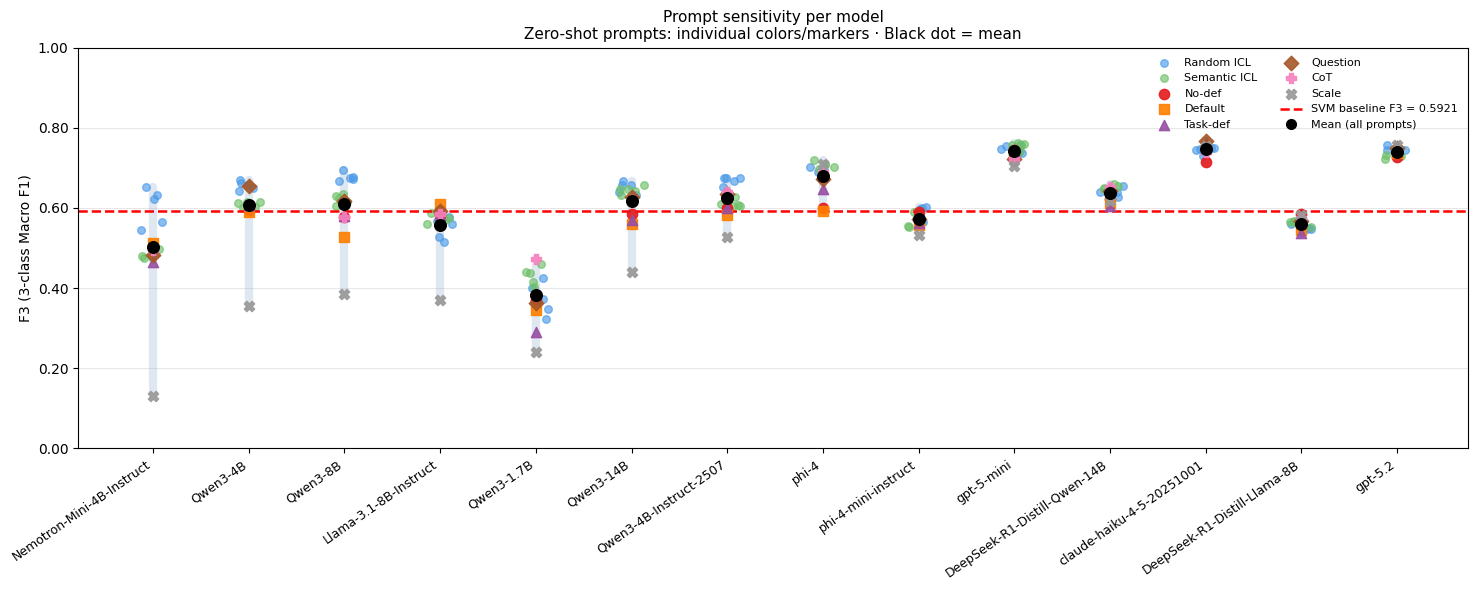

In [107]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

ZERO_SHOT_PROMPTS    = ["default_no_label_definitions","default","task_definition","question","cot","task_definition_scale"]
RANDOM_ICL_PROMPTS   = ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"]
SEMANTIC_ICL_PROMPTS = ["semantic_icl_3","semantic_icl_6","semantic_icl_9","semantic_icl_12","semantic_icl_15"]

PROMPT_GROUP = {
    **{p: "Zero-shot"    for p in ZERO_SHOT_PROMPTS},
    **{p: "Random ICL"   for p in RANDOM_ICL_PROMPTS},
    **{p: "Semantic ICL" for p in SEMANTIC_ICL_PROMPTS},
}
llm_df["group"] = llm_df["prompt"].map(PROMPT_GROUP)

ZS_STYLES = {
    "default_no_label_definitions": ("#e41a1c", "o", "No-def"),
    "default":                      ("#ff7f00", "s", "Default"),
    "task_definition":              ("#984ea3", "^", "Task-def"),
    "question":                     ("#a65628", "D", "Question"),
    "cot":                          ("#f781bf", "P", "CoT"),
    "task_definition_scale":        ("#999999", "X", "Scale"),
}
ICL_COLOR = {"Random ICL": "#4C9BE8", "Semantic ICL": "#6DBF67"}

# ── Table 21a: per-model sensitivity ───────────────────────────────────────
sens_rows = []
for model, grp in llm_df.groupby("model"):
    best_idx  = grp["3class_macro_f1"].idxmax()
    worst_idx = grp["3class_macro_f1"].idxmin()
    sens_rows.append({
        "model_short":  model.split("/")[-1] if "/" in model else model,
        "std_f3":       grp["3class_macro_f1"].std(),
        "range_f3":     grp["3class_macro_f1"].max() - grp["3class_macro_f1"].min(),
        "mean_f3":      grp["3class_macro_f1"].mean(),
        "min_f3":       grp["3class_macro_f1"].min(),
        "max_f3":       grp["3class_macro_f1"].max(),
        "best_prompt":  PROMPT_LABELS_CHART.get(grp.loc[best_idx,  "prompt"], grp.loc[best_idx,  "prompt"]),
        "worst_prompt": PROMPT_LABELS_CHART.get(grp.loc[worst_idx, "prompt"], grp.loc[worst_idx, "prompt"]),
    })

sens_df = pd.DataFrame(sens_rows).sort_values("range_f3", ascending=False).reset_index(drop=True)

print("=== Table 21a: Prompt Sensitivity per Model (sorted by F3 range) ===\n")
hdr = f"{'Model':<35} {'Std':>6} {'Range':>7} {'Min F3':>7} {'Max F3':>7} {'Best Prompt':<18} {'Worst Prompt':<18}"
print(hdr)
print("─" * len(hdr))
for _, r in sens_df.iterrows():
    print(f"{r['model_short']:<35} {r['std_f3']:>6.4f} {r['range_f3']:>7.4f} "
          f"{r['min_f3']:>7.4f} {r['max_f3']:>7.4f} "
          f"{r['best_prompt']:<18} {r['worst_prompt']:<18}")

# ── Plot 21b ───────────────────────────────────────────────────────────────
models_s   = sens_df["model_short"].tolist()
model_rank = {m: i for i, m in enumerate(models_s)}
x          = np.arange(len(models_s))
rng        = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(15, 6))

for i, (_, r) in enumerate(sens_df.iterrows()):
    ax.plot([i, i], [r["min_f3"], r["max_f3"]],
            color="lightsteelblue", linewidth=6, alpha=0.4, solid_capstyle="round", zorder=1)

for icl_prompts, label in [(RANDOM_ICL_PROMPTS, "Random ICL"), (SEMANTIC_ICL_PROMPTS, "Semantic ICL")]:
    sub = llm_df[llm_df["prompt"].isin(icl_prompts)].copy()
    sub["model_short"] = sub["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
    sub = sub[sub["model_short"].isin(model_rank)]
    xi  = sub["model_short"].map(model_rank).values
    jitter = (rng.random(len(sub)) - 0.5) * 0.28
    ax.scatter(xi + jitter, sub["3class_macro_f1"].values,
               color=ICL_COLOR[label], s=30, alpha=0.65, zorder=2, label=label)

for prompt, (color, marker, label) in ZS_STYLES.items():
    sub = llm_df[llm_df["prompt"] == prompt].copy()
    sub["model_short"] = sub["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
    sub = sub[sub["model_short"].isin(model_rank)]
    xi  = sub["model_short"].map(model_rank).values
    ax.scatter(xi, sub["3class_macro_f1"].values,
               color=color, marker=marker, s=55, alpha=0.9, zorder=4, label=label)

for i, (_, r) in enumerate(sens_df.iterrows()):
    ax.scatter(i, r["mean_f3"], color="black", s=70, zorder=6)

ax.axhline(SVM_F2_TUNED_3CLASS, color="red", linestyle="--", linewidth=1.8,
           label=f"SVM baseline F3 = {SVM_F2_TUNED_3CLASS:.4f}")

ax.set_xticks(x)
ax.set_xticklabels(models_s, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("F3 (3-class Macro F1)", fontsize=10)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.grid(axis="y", alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color="black", marker="o", linestyle="None",
                              markersize=7, label="Mean (all prompts)"))
labels.append("Mean (all prompts)")
ax.legend(handles=handles, labels=labels, fontsize=8, frameon=False, loc="upper right", ncol=2)
ax.set_title(
    "Prompt sensitivity per model\n"
    "Zero-shot prompts: individual colors/markers · Black dot = mean",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Step 22: F3 by Prompt Family — Grouped Bar Chart per Family

Five subplots, one per prompt family, sharing the same model x-axis.  
**Bar** = mean F3 of that family for each model.  
**Horizontal lines inside bar** = individual prompt F3 values (line style differentiates prompts within family).  
**Red dashed line** = SVM baseline F3.  
Models sorted by overall mean F3 descending (best → left).

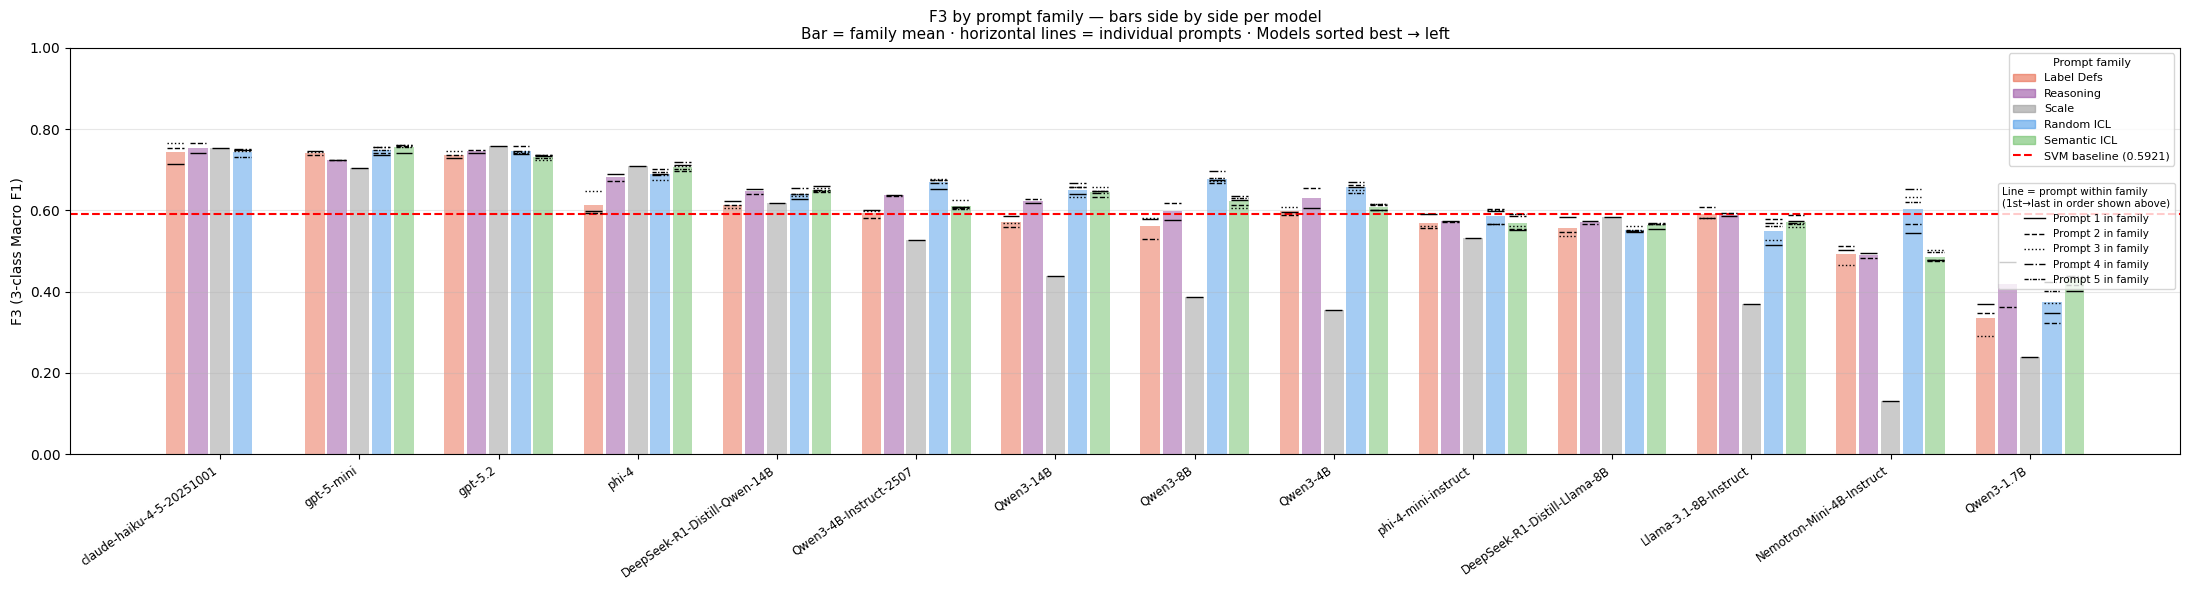

In [108]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
from collections import OrderedDict

FAMILIES = OrderedDict([
    ("Label Defs",   {
        "prompts": ["default_no_label_definitions", "default", "task_definition"],
        "labels":  ["No-def", "Default", "Task-def"],
        "color":   "#E8694C",
        "styles":  ["-", "--", ":"],
    }),
    ("Reasoning",    {
        "prompts": ["cot", "question"],
        "labels":  ["CoT", "Question"],
        "color":   "#984ea3",
        "styles":  ["-", "--"],
    }),
    ("Scale",        {
        "prompts": ["task_definition_scale"],
        "labels":  ["Scale"],
        "color":   "#999999",
        "styles":  ["-"],
    }),
    ("Random ICL",   {
        "prompts": ["few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15"],
        "labels":  ["3R", "6R", "9R", "12R", "15R"],
        "color":   "#4C9BE8",
        "styles":  ["-", "--", ":", "-.", (0, (3, 1, 1, 1))],
    }),
    ("Semantic ICL", {
        "prompts": ["semantic_icl_3", "semantic_icl_6", "semantic_icl_9", "semantic_icl_12", "semantic_icl_15"],
        "labels":  ["3S", "6S", "9S", "12S", "15S"],
        "color":   "#6DBF67",
        "styles":  ["-", "--", ":", "-.", (0, (3, 1, 1, 1))],
    }),
])

family_names = list(FAMILIES.keys())
n_fam  = len(family_names)
bar_w  = 0.14
gap    = 0.02
step   = bar_w + gap
offsets = np.arange(n_fam) * step
offsets -= offsets.mean()   # centre the group around each model tick

model_order = (
    llm_df.groupby("model")["3class_macro_f1"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)
model_short_map = {m: (m.split("/")[-1] if "/" in m else m) for m in model_order}
model_labels    = [model_short_map[m] for m in model_order]
x = np.arange(len(model_order))

fig, ax = plt.subplots(figsize=(22, 6))

for fam_idx, (fam_name, fam) in enumerate(FAMILIES.items()):
    color   = fam["color"]
    prompts = fam["prompts"]
    styles  = fam["styles"]
    fam_df  = llm_df[llm_df["prompt"].isin(prompts)].copy()
    xi_off  = offsets[fam_idx]

    for xi, model in enumerate(model_order):
        mdf = fam_df[fam_df["model"] == model]
        if mdf.empty:
            continue
        mean_f3 = mdf["3class_macro_f1"].mean()

        # bar
        ax.bar(x[xi] + xi_off, mean_f3, width=bar_w,
               color=color, alpha=0.5, zorder=1, edgecolor="none")

        # horizontal lines inside bar (thinner)
        for prompt, style in zip(prompts, styles):
            row = mdf[mdf["prompt"] == prompt]
            if row.empty:
                continue
            f3_val = row["3class_macro_f1"].values[0]
            ax.hlines(f3_val,
                      x[xi] + xi_off - bar_w / 2 + 0.01,
                      x[xi] + xi_off + bar_w / 2 - 0.01,
                      colors="black", linestyles=style, linewidth=1.0, zorder=3)

# SVM baseline
ax.axhline(SVM_F2_TUNED_3CLASS, color="red", linestyle="--",
           linewidth=1.5, zorder=2, label=f"SVM baseline F3 = {SVM_F2_TUNED_3CLASS:.4f}")

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("F3 (3-class Macro F1)", fontsize=10)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.grid(axis="y", alpha=0.3)

# ── Legend ──────────────────────────────────────────────────────────────────
# Family colour patches
fam_patches = [
    mpatches.Patch(color=fam["color"], alpha=0.6, label=name)
    for name, fam in FAMILIES.items()
]
# Line-style guide (shared across families: same styles used in same order)
style_lines = [
    mlines.Line2D([], [], color="black", linestyle=s, linewidth=1.0,
                  label=f"Prompt {i+1} in family")
    for i, s in enumerate(["-", "--", ":", "-.", (0, (3, 1, 1, 1))])
]
svm_line = mlines.Line2D([], [], color="red", linestyle="--",
                          linewidth=1.5, label=f"SVM baseline ({SVM_F2_TUNED_3CLASS:.4f})")

legend1 = ax.legend(handles=fam_patches + [svm_line],
                    title="Prompt family", fontsize=8, title_fontsize=8,
                    frameon=True, loc="upper right", bbox_to_anchor=(1.0, 1.0))
ax.add_artist(legend1)
ax.legend(handles=style_lines,
          title="Line = prompt within family\n(1st→last in order shown above)",
          fontsize=7.5, title_fontsize=7.5,
          frameon=True, loc="upper right", bbox_to_anchor=(1.0, 0.68))

ax.set_title(
    "F3 by prompt family — bars side by side per model\n"
    "Bar = family mean · horizontal lines = individual prompts · Models sorted best → left",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Step 23: Random ICL vs Semantic ICL — Best Score per Model

Per-model table: best Random ICL F3 (with shot count), best Semantic ICL F3 (with shot count), which paradigm won, and best overall prompt.

In [109]:
RANDOM_ICL_PROMPTS   = ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"]
SEMANTIC_ICL_PROMPTS = ["semantic_icl_3","semantic_icl_6","semantic_icl_9","semantic_icl_12","semantic_icl_15"]

SHOT_LABEL = {
    "few_shot_3": "3R", "few_shot_6": "6R", "few_shot_9": "9R",
    "few_shot_12": "12R", "few_shot_15": "15R",
    "semantic_icl_3": "3S", "semantic_icl_6": "6S", "semantic_icl_9": "9S",
    "semantic_icl_12": "12S", "semantic_icl_15": "15S",
}

# model order: best overall mean F3 first
model_order = _ordered_models(llm_df)

rows = []
for model in model_order:
    mdf = llm_df[llm_df["model"] == model]
    short = model.split("/")[-1] if "/" in model else model

    # best random ICL
    rand_df = mdf[mdf["prompt"].isin(RANDOM_ICL_PROMPTS)]
    if not rand_df.empty:
        best_rand_idx = rand_df["3class_macro_f1"].idxmax()
        best_rand_f3  = rand_df.loc[best_rand_idx, "3class_macro_f1"]
        best_rand_lbl = SHOT_LABEL[rand_df.loc[best_rand_idx, "prompt"]]
    else:
        best_rand_f3, best_rand_lbl = float("nan"), "-"

    # best semantic ICL
    sem_df = mdf[mdf["prompt"].isin(SEMANTIC_ICL_PROMPTS)]
    if not sem_df.empty:
        best_sem_idx = sem_df["3class_macro_f1"].idxmax()
        best_sem_f3  = sem_df.loc[best_sem_idx, "3class_macro_f1"]
        best_sem_lbl = SHOT_LABEL[sem_df.loc[best_sem_idx, "prompt"]]
    else:
        best_sem_f3, best_sem_lbl = float("nan"), "-"

    # which ICL paradigm won
    if best_rand_f3 > best_sem_f3:
        winner = "Random"
    elif best_sem_f3 > best_rand_f3:
        winner = "Semantic"
    else:
        winner = "Tie"

    # best overall prompt
    best_overall_idx = mdf["3class_macro_f1"].idxmax()
    best_overall_f3  = mdf.loc[best_overall_idx, "3class_macro_f1"]
    best_overall_lbl = PROMPT_LABELS_CHART.get(mdf.loc[best_overall_idx, "prompt"],
                                                mdf.loc[best_overall_idx, "prompt"])

    rows.append({
        "model": short,
        "best_rand_f3":  best_rand_f3,
        "best_rand_lbl": best_rand_lbl,
        "best_sem_f3":   best_sem_f3,
        "best_sem_lbl":  best_sem_lbl,
        "winner":        winner,
        "best_f3":       best_overall_f3,
        "best_prompt":   best_overall_lbl,
    })

# ── Print table ─────────────────────────────────────────────────────────────
hdr = (f"{'Model':<35} {'Best Random ICL':>16} {'Best Semantic ICL':>18} "
       f"{'Better':>9} {'Best Overall':>14}")
print("=== Random ICL vs Semantic ICL — best F3 per model ===\n")
print(hdr)
print("─" * len(hdr))
for r in rows:
    rand_str    = f"{r['best_rand_f3']:.4f} ({r['best_rand_lbl']})"
    sem_str     = f"{r['best_sem_f3']:.4f} ({r['best_sem_lbl']})"
    overall_str = f"{r['best_f3']:.4f} ({r['best_prompt']})"
    print(f"{r['model']:<35} {rand_str:>16} {sem_str:>18} "
          f"{r['winner']:>9} {overall_str:>14}")

=== Random ICL vs Semantic ICL — best F3 per model ===

Model                                Best Random ICL  Best Semantic ICL    Better   Best Overall
────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5.2                                  0.7580 (6R)       0.7366 (12S)    Random 0.7581 (Scale)
gpt-5-mini                               0.7564 (9R)        0.7610 (9S)  Semantic    0.7610 (9S)
claude-haiku-4-5-20251001               0.7506 (12R)            nan (-)       Tie 0.7660 (Question)
DeepSeek-R1-Distill-Qwen-14B            0.6554 (12R)        0.6588 (3S)  Semantic    0.6588 (3S)
Qwen3-14B                               0.6682 (12R)        0.6586 (9S)    Random   0.6682 (12R)
phi-4                                    0.7025 (6R)       0.7186 (12S)  Semantic   0.7186 (12S)
Qwen3-8B                                0.6959 (12R)       0.6345 (12S)    Random   0.6959 (12R)
DeepSeek-R1-Distill-Llama-8B             0.5606 (9R)       0.5685 (1

## Step 24: Per-target Analysis — Label Distribution + Per-class F1

4-row × 5-column grid:
- **Row 0**: Train vs test label distribution per target (proportions)
- **Row 1–3**: FAVOR / AGAINST / NONE F1 per target — all LLMs as dots (mean ± std across prompts), SVM dashed line. Filled = above SVM, hollow = below SVM.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5574/2312281184.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap     = plt.cm.get_cmap("tab20", n_models)


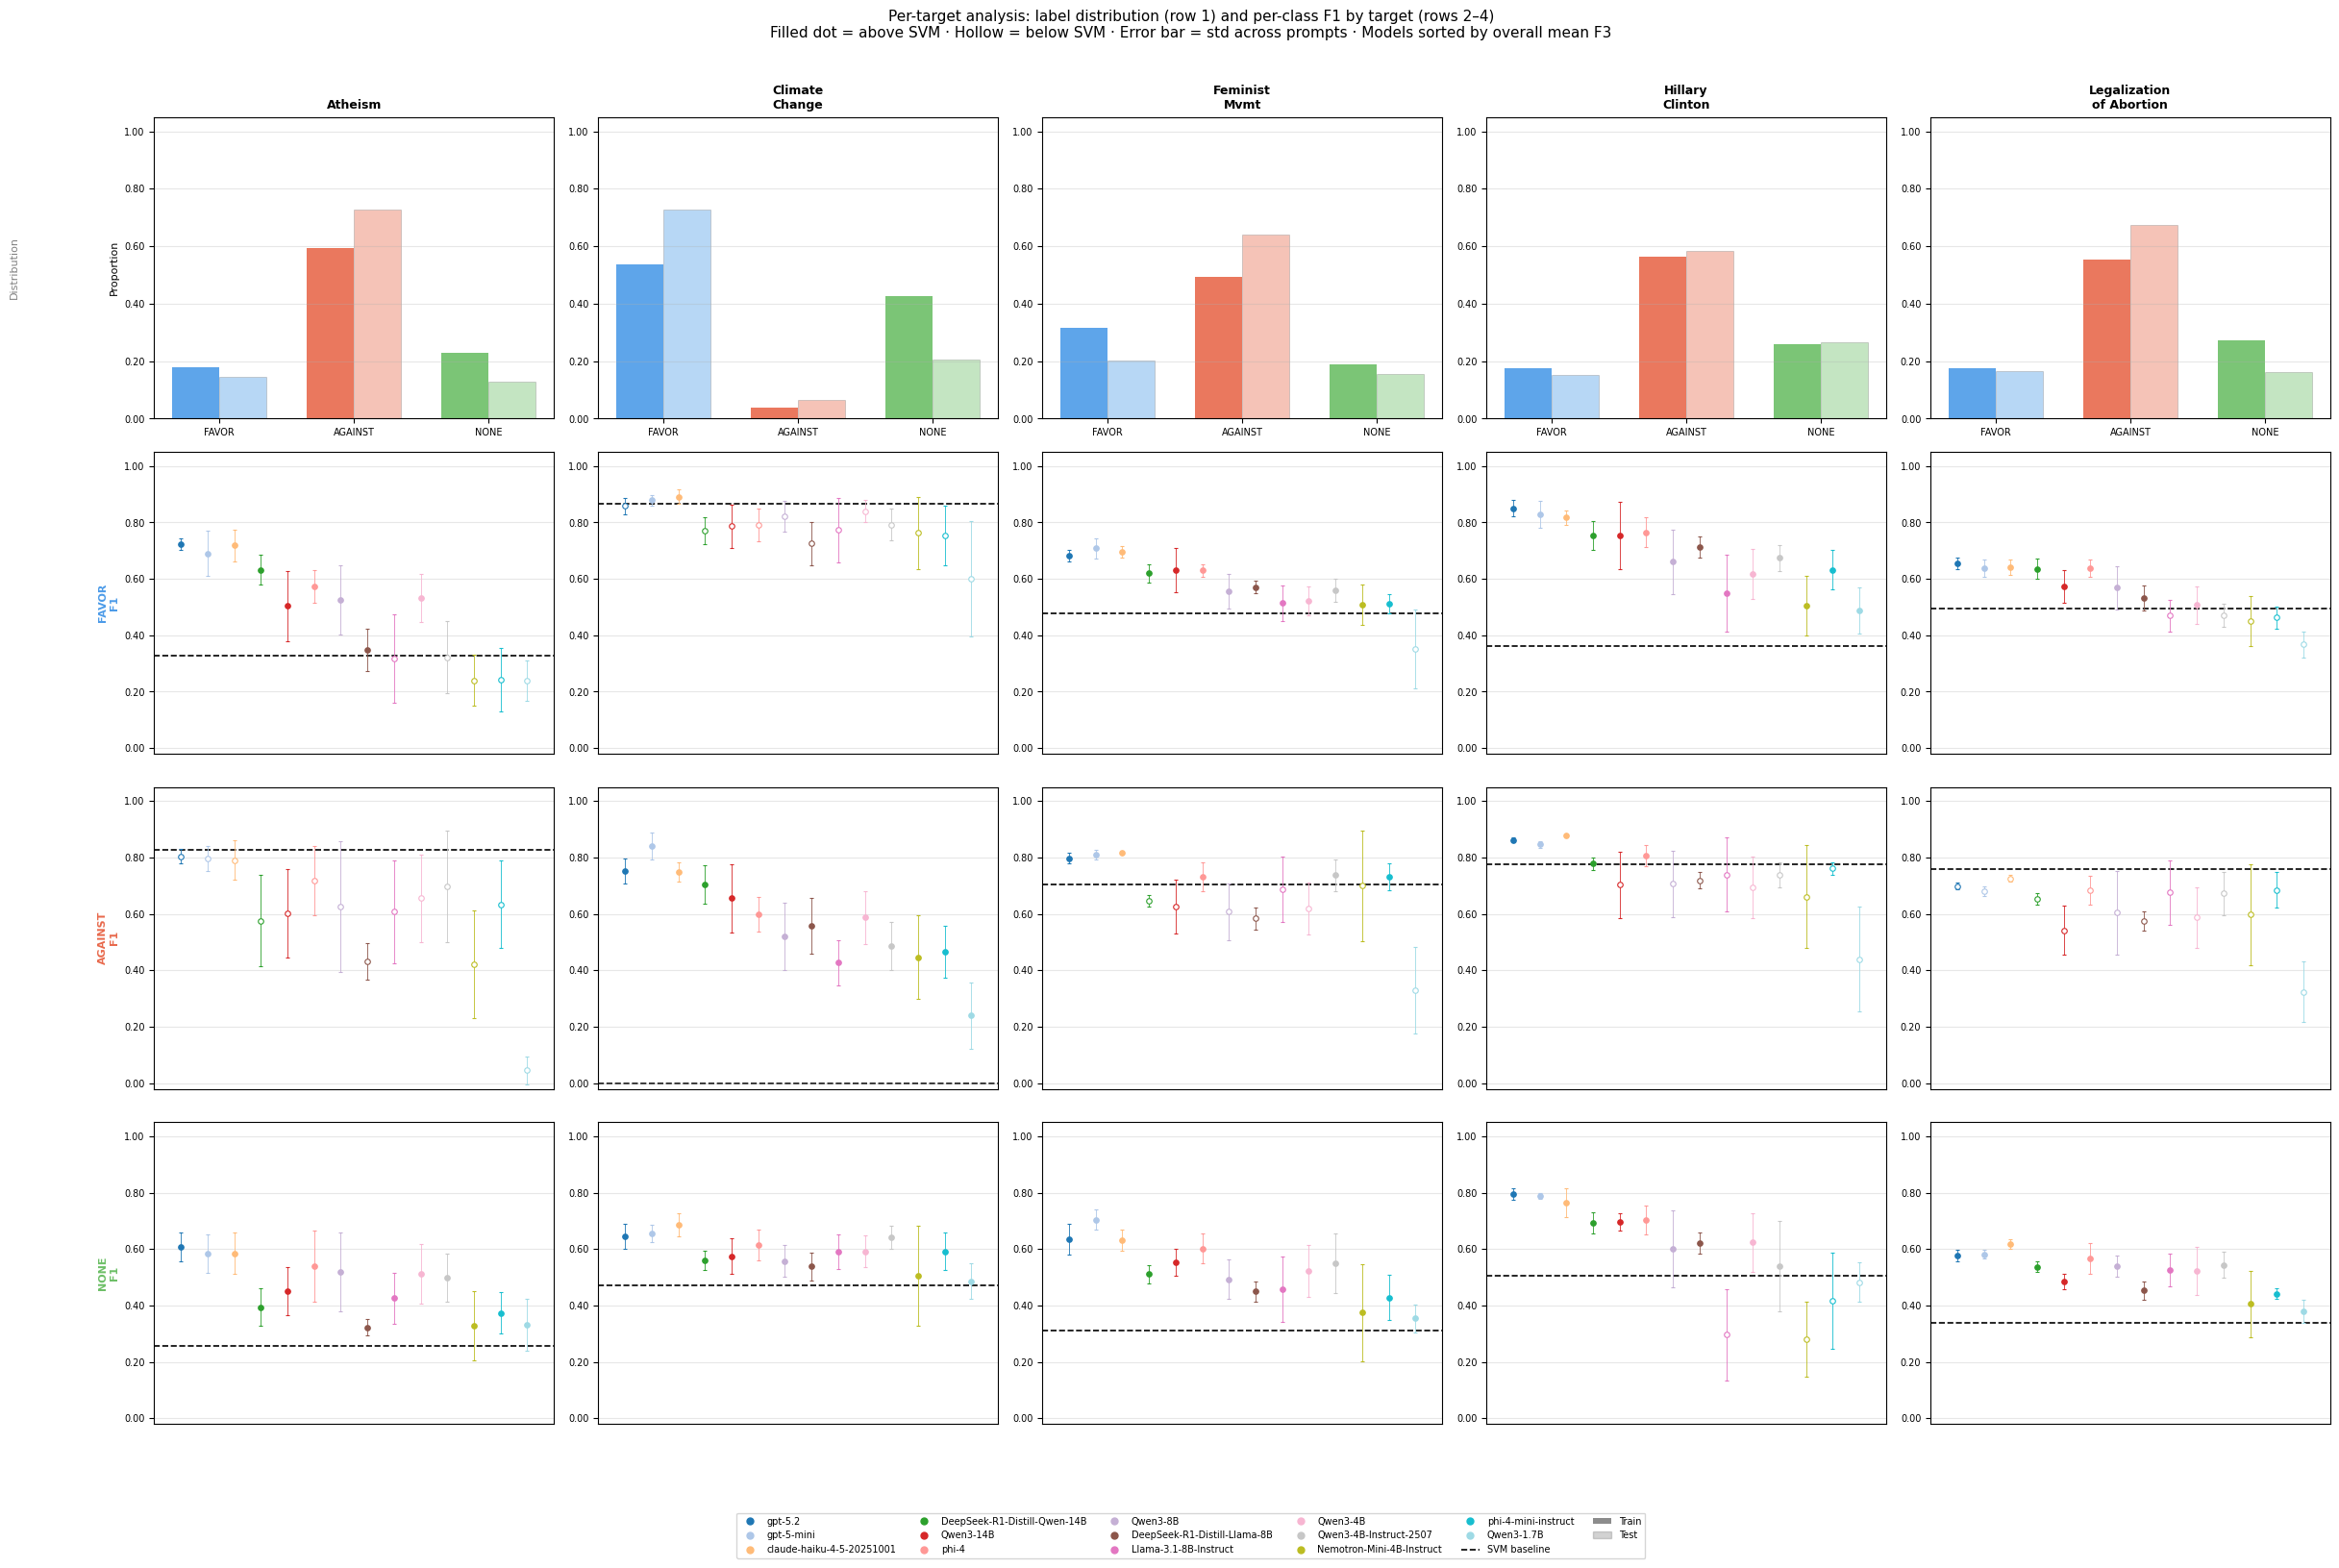

In [110]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

TARGET_ORDER = [
    "Atheism",
    "Climate Change is a Real Concern",
    "Feminist Movement",
    "Hillary Clinton",
    "Legalization of Abortion",
]
TARGET_SHORT = {
    "Atheism":                          "Atheism",
    "Climate Change is a Real Concern": "Climate\nChange",
    "Feminist Movement":                "Feminist\nMvmt",
    "Hillary Clinton":                  "Hillary\nClinton",
    "Legalization of Abortion":         "Legalization\nof Abortion",
}
CLASSES     = ["FAVOR", "AGAINST", "NONE"]
CLASS_COLOR = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}
CLS_COL     = {"FAVOR": "f_favor", "AGAINST": "f_against", "NONE": "f_none"}

# ── 1. Per-target label distributions ────────────────────────────────────────
train_dist, test_dist = {}, {}
for tgt in TARGET_ORDER:
    tr = train_df[train_df["query"] == tgt]["stance_label_original"].value_counts()
    te = test_df[test_df["query"] == tgt]["stance_label"].value_counts()
    train_dist[tgt] = {c: tr.get(c, 0) for c in CLASSES}
    test_dist[tgt]  = {c: te.get(c, 0) for c in CLASSES}

# ── 2. SVM per-target per-class F1 (F3-tuned) ────────────────────────────────
svm_target_f1 = {}
for tgt in TARGET_ORDER:
    rows = [r for r in all_preds_f3 if r["target"] == tgt]
    yt = [r["true"] for r in rows]
    yp = [r["pred"] for r in rows]
    _, _, f_vals, _ = precision_recall_fscore_support(yt, yp, labels=CLASSES, zero_division=0)
    svm_target_f1[tgt] = dict(zip(CLASSES, f_vals))

# ── 3. LLM per-target per-class F1 (reload from CSVs) ────────────────────────
llm_target_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_1249"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].astype(str).str.upper().str.strip()
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue
    for tgt in TARGET_ORDER:
        sub = df[df["query"] == tgt]
        if len(sub) == 0:
            continue
        yt = sub["original_stance"].tolist()
        yp = sub["predicted_stance"].tolist()
        _, _, f_vals, _ = precision_recall_fscore_support(yt, yp, labels=CLASSES, zero_division=0)
        llm_target_rows.append({
            "model": model, "prompt": prompt, "target": tgt,
            "f_favor": f_vals[0], "f_against": f_vals[1], "f_none": f_vals[2],
        })

llm_target_df = pd.DataFrame(llm_target_rows)

# model order from overall mean F3
model_order_tgt = _ordered_models(llm_df)
n_models = len(model_order_tgt)
cmap     = plt.cm.get_cmap("tab20", n_models)

# ── 4. Build figure ───────────────────────────────────────────────────────────
import matplotlib.ticker as mticker

fig, axes = plt.subplots(4, 5, figsize=(24, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.35)

x_cls = np.arange(len(CLASSES))
bar_w = 0.35

for col, tgt in enumerate(TARGET_ORDER):
    # ── Row 0: label distributions ───────────────────────────────────────────
    ax = axes[0, col]
    total_tr = sum(train_dist[tgt].values())
    total_te = sum(test_dist[tgt].values())
    tr_pct = [train_dist[tgt][c] / total_tr for c in CLASSES]
    te_pct = [test_dist[tgt][c]  / total_te for c in CLASSES]
    colors = [CLASS_COLOR[c] for c in CLASSES]
    ax.bar(x_cls - bar_w / 2, tr_pct, bar_w, color=colors, alpha=0.9)
    ax.bar(x_cls + bar_w / 2, te_pct, bar_w, color=colors, alpha=0.4,
           edgecolor="grey", linewidth=0.6)
    ax.set_xticks(x_cls)
    ax.set_xticklabels(CLASSES, fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.set_ylim(0, 1.05)
    ax.set_title(TARGET_SHORT[tgt], fontsize=9, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="y", alpha=0.3)
    if col == 0:
        ax.set_ylabel("Proportion", fontsize=8)

    # ── Rows 1–3: per-class F1 ────────────────────────────────────────────────
    for row_idx, cls in enumerate(CLASSES):
        ax      = axes[row_idx + 1, col]
        col_key = CLS_COL[cls]
        svm_f1  = svm_target_f1[tgt][cls]
        ax.axhline(svm_f1, color="black", linestyle="--", linewidth=1.2, zorder=1)

        sub = llm_target_df[llm_target_df["target"] == tgt]
        for m_idx, model in enumerate(model_order_tgt):
            mdf = sub[sub["model"] == model][col_key]
            if mdf.empty:
                continue
            mean_f1 = mdf.mean()
            std_f1  = mdf.std() if len(mdf) > 1 else 0.0
            color   = cmap(m_idx)
            fc      = color if mean_f1 >= svm_f1 else "white"
            ax.errorbar(
                m_idx, mean_f1, yerr=std_f1,
                fmt="o", markersize=4,
                markerfacecolor=fc, markeredgecolor=color, markeredgewidth=0.8,
                ecolor=color, elinewidth=0.6, capsize=1.5, zorder=2,
            )

        ax.set_xlim(-1, n_models)
        ax.set_ylim(-0.02, 1.05)
        ax.set_xticks([])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(axis="y", alpha=0.3)
        if col == 0:
            ax.set_ylabel(f"{cls}\nF1", fontsize=8,
                          color=CLASS_COLOR[cls], fontweight="bold")

# ── Row label ─────────────────────────────────────────────────────────────────
axes[0, 0].annotate("Distribution", xy=(-0.35, 0.5), xycoords="axes fraction",
                     fontsize=8, rotation=90, va="center", ha="center", color="grey")

# ── Legend ────────────────────────────────────────────────────────────────────
model_handles = [
    mlines.Line2D([], [], color=cmap(i), marker="o", linestyle="None",
                  markersize=5, label=m.split("/")[-1] if "/" in m else m)
    for i, m in enumerate(model_order_tgt)
]
model_handles += [
    mlines.Line2D([], [], color="black", linestyle="--", linewidth=1.2, label="SVM baseline"),
    mpatches.Patch(facecolor="grey", alpha=0.9, label="Train"),
    mpatches.Patch(facecolor="grey", alpha=0.35, edgecolor="grey", label="Test"),
]
fig.legend(
    handles=model_handles,
    loc="lower center", ncol=6, fontsize=7,
    bbox_to_anchor=(0.5, -0.03), frameon=True,
)

fig.suptitle(
    "Per-target analysis: label distribution (row 1) and per-class F1 by target (rows 2–4)\n"
    "Filled dot = above SVM · Hollow = below SVM · Error bar = std across prompts · Models sorted by overall mean F3",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

## Step 25: Per-target Overall F3 — Table + Chart

=== Per-target Overall F3 (mean across all prompts) ===

Model                                                 Atheism            Climate Change             Feminist Mvmt           Hillary Clinton  Legalization of Abortion
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
SVM baseline                                           0.4703                    0.4468                    0.4977                    0.5468                    0.5306
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5.2                                                0.7117                    0.7519                    0.7047                    0.8363                    0.6437
gpt-5-mini                                             0.6902                    0.7914                    0.7413

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5574/2586915395.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap("tab20", n_models)


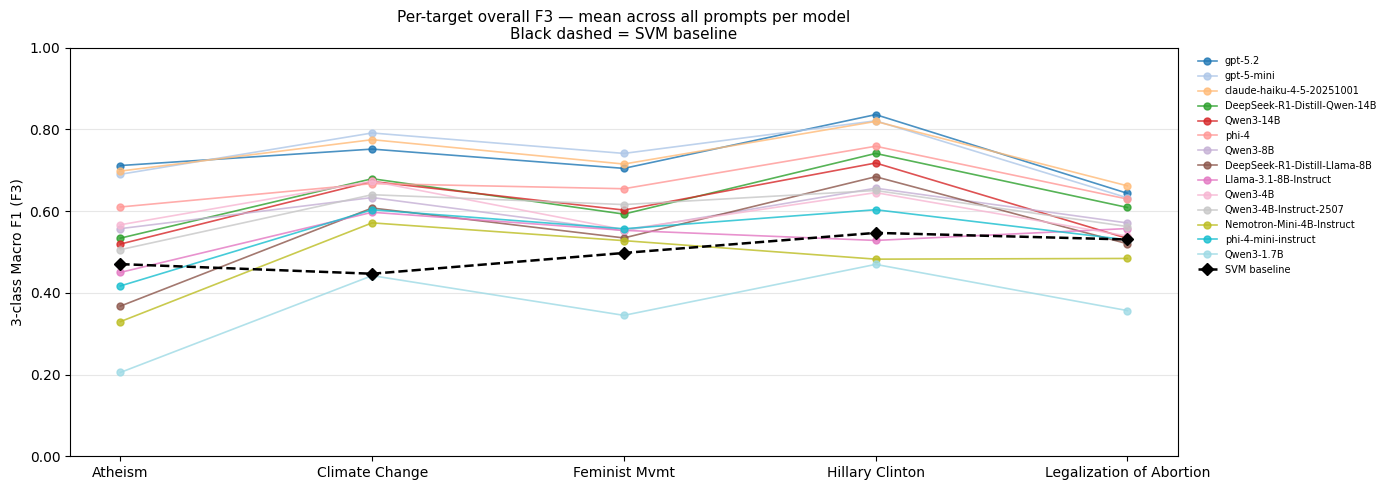

In [111]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

TARGET_SHORT_FLAT = {
    "Atheism":                          "Atheism",
    "Climate Change is a Real Concern": "Climate Change",
    "Feminist Movement":                "Feminist Mvmt",
    "Hillary Clinton":                  "Hillary Clinton",
    "Legalization of Abortion":         "Legalization of Abortion",
}

# ── Compute per-target macro F1 for LLMs ─────────────────────────────────────
llm_target_df["macro_f1"] = (
    llm_target_df["f_favor"] + llm_target_df["f_against"] + llm_target_df["f_none"]
) / 3

# mean across prompts per model × target
llm_tgt_mean = (
    llm_target_df.groupby(["model", "target"])["macro_f1"]
    .mean()
    .reset_index()
    .rename(columns={"macro_f1": "mean_f3"})
)
llm_tgt_mean["model_short"] = llm_tgt_mean["model"].apply(
    lambda m: m.split("/")[-1] if "/" in m else m
)

# ── SVM per-target F3 from results_f3 ────────────────────────────────────────
svm_tgt = {r["target"]: r["3class_macro_f1"] for r in results_f3}

# ── Print table ───────────────────────────────────────────────────────────────
col_width = 26
targets_flat = [TARGET_SHORT_FLAT[t] for t in TARGET_ORDER]

header = f"{'Model':<35}" + "".join(f"{t:>{col_width}}" for t in targets_flat)
sep    = "─" * len(header)
print("=== Per-target Overall F3 (mean across all prompts) ===\n")
print(header)
print(sep)

# SVM row
svm_vals = [svm_tgt.get(t, float("nan")) for t in TARGET_ORDER]
print(f"{'SVM baseline':<35}" + "".join(f"{v:>{col_width}.4f}" for v in svm_vals))
print(sep)

for model in model_order_tgt:
    short = model.split("/")[-1] if "/" in model else model
    vals  = []
    for tgt in TARGET_ORDER:
        row = llm_tgt_mean[(llm_tgt_mean["model"] == model) & (llm_tgt_mean["target"] == tgt)]
        vals.append(row["mean_f3"].values[0] if not row.empty else float("nan"))
    print(f"{short:<35}" + "".join(f"{v:>{col_width}.4f}" for v in vals))

# ── Chart: per-target F3, all models ─────────────────────────────────────────
n_models  = len(model_order_tgt)
cmap      = plt.cm.get_cmap("tab20", n_models)
x         = np.arange(len(TARGET_ORDER))
x_labels  = [TARGET_SHORT_FLAT[t] for t in TARGET_ORDER]

fig, ax = plt.subplots(figsize=(14, 5))

for m_idx, model in enumerate(model_order_tgt):
    short = model.split("/")[-1] if "/" in model else model
    vals  = []
    for tgt in TARGET_ORDER:
        row = llm_tgt_mean[(llm_tgt_mean["model"] == model) & (llm_tgt_mean["target"] == tgt)]
        vals.append(row["mean_f3"].values[0] if not row.empty else float("nan"))
    ax.plot(x, vals, marker="o", linewidth=1.2, markersize=5,
            color=cmap(m_idx), alpha=0.8, label=short)

# SVM dashed line per target (connect the dots)
ax.plot(x, svm_vals, marker="D", markersize=6, linewidth=1.8,
        color="black", linestyle="--", label="SVM baseline", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel("3-class Macro F1 (F3)", fontsize=10)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.grid(axis="y", alpha=0.3)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, frameon=False)
ax.set_title(
    "Per-target overall F3 — mean across all prompts per model\n"
    "Black dashed = SVM baseline",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Step 26: Predicted Distribution per Prompt — per Model

Selected prompts: all 6 zero-shot + best random ICL + best semantic ICL (auto-picked by mean F3).  
Bars = predicted class % per prompt. Dotted lines = gold test distribution per class.

Best random ICL: 12R  |  Best semantic ICL: 15S


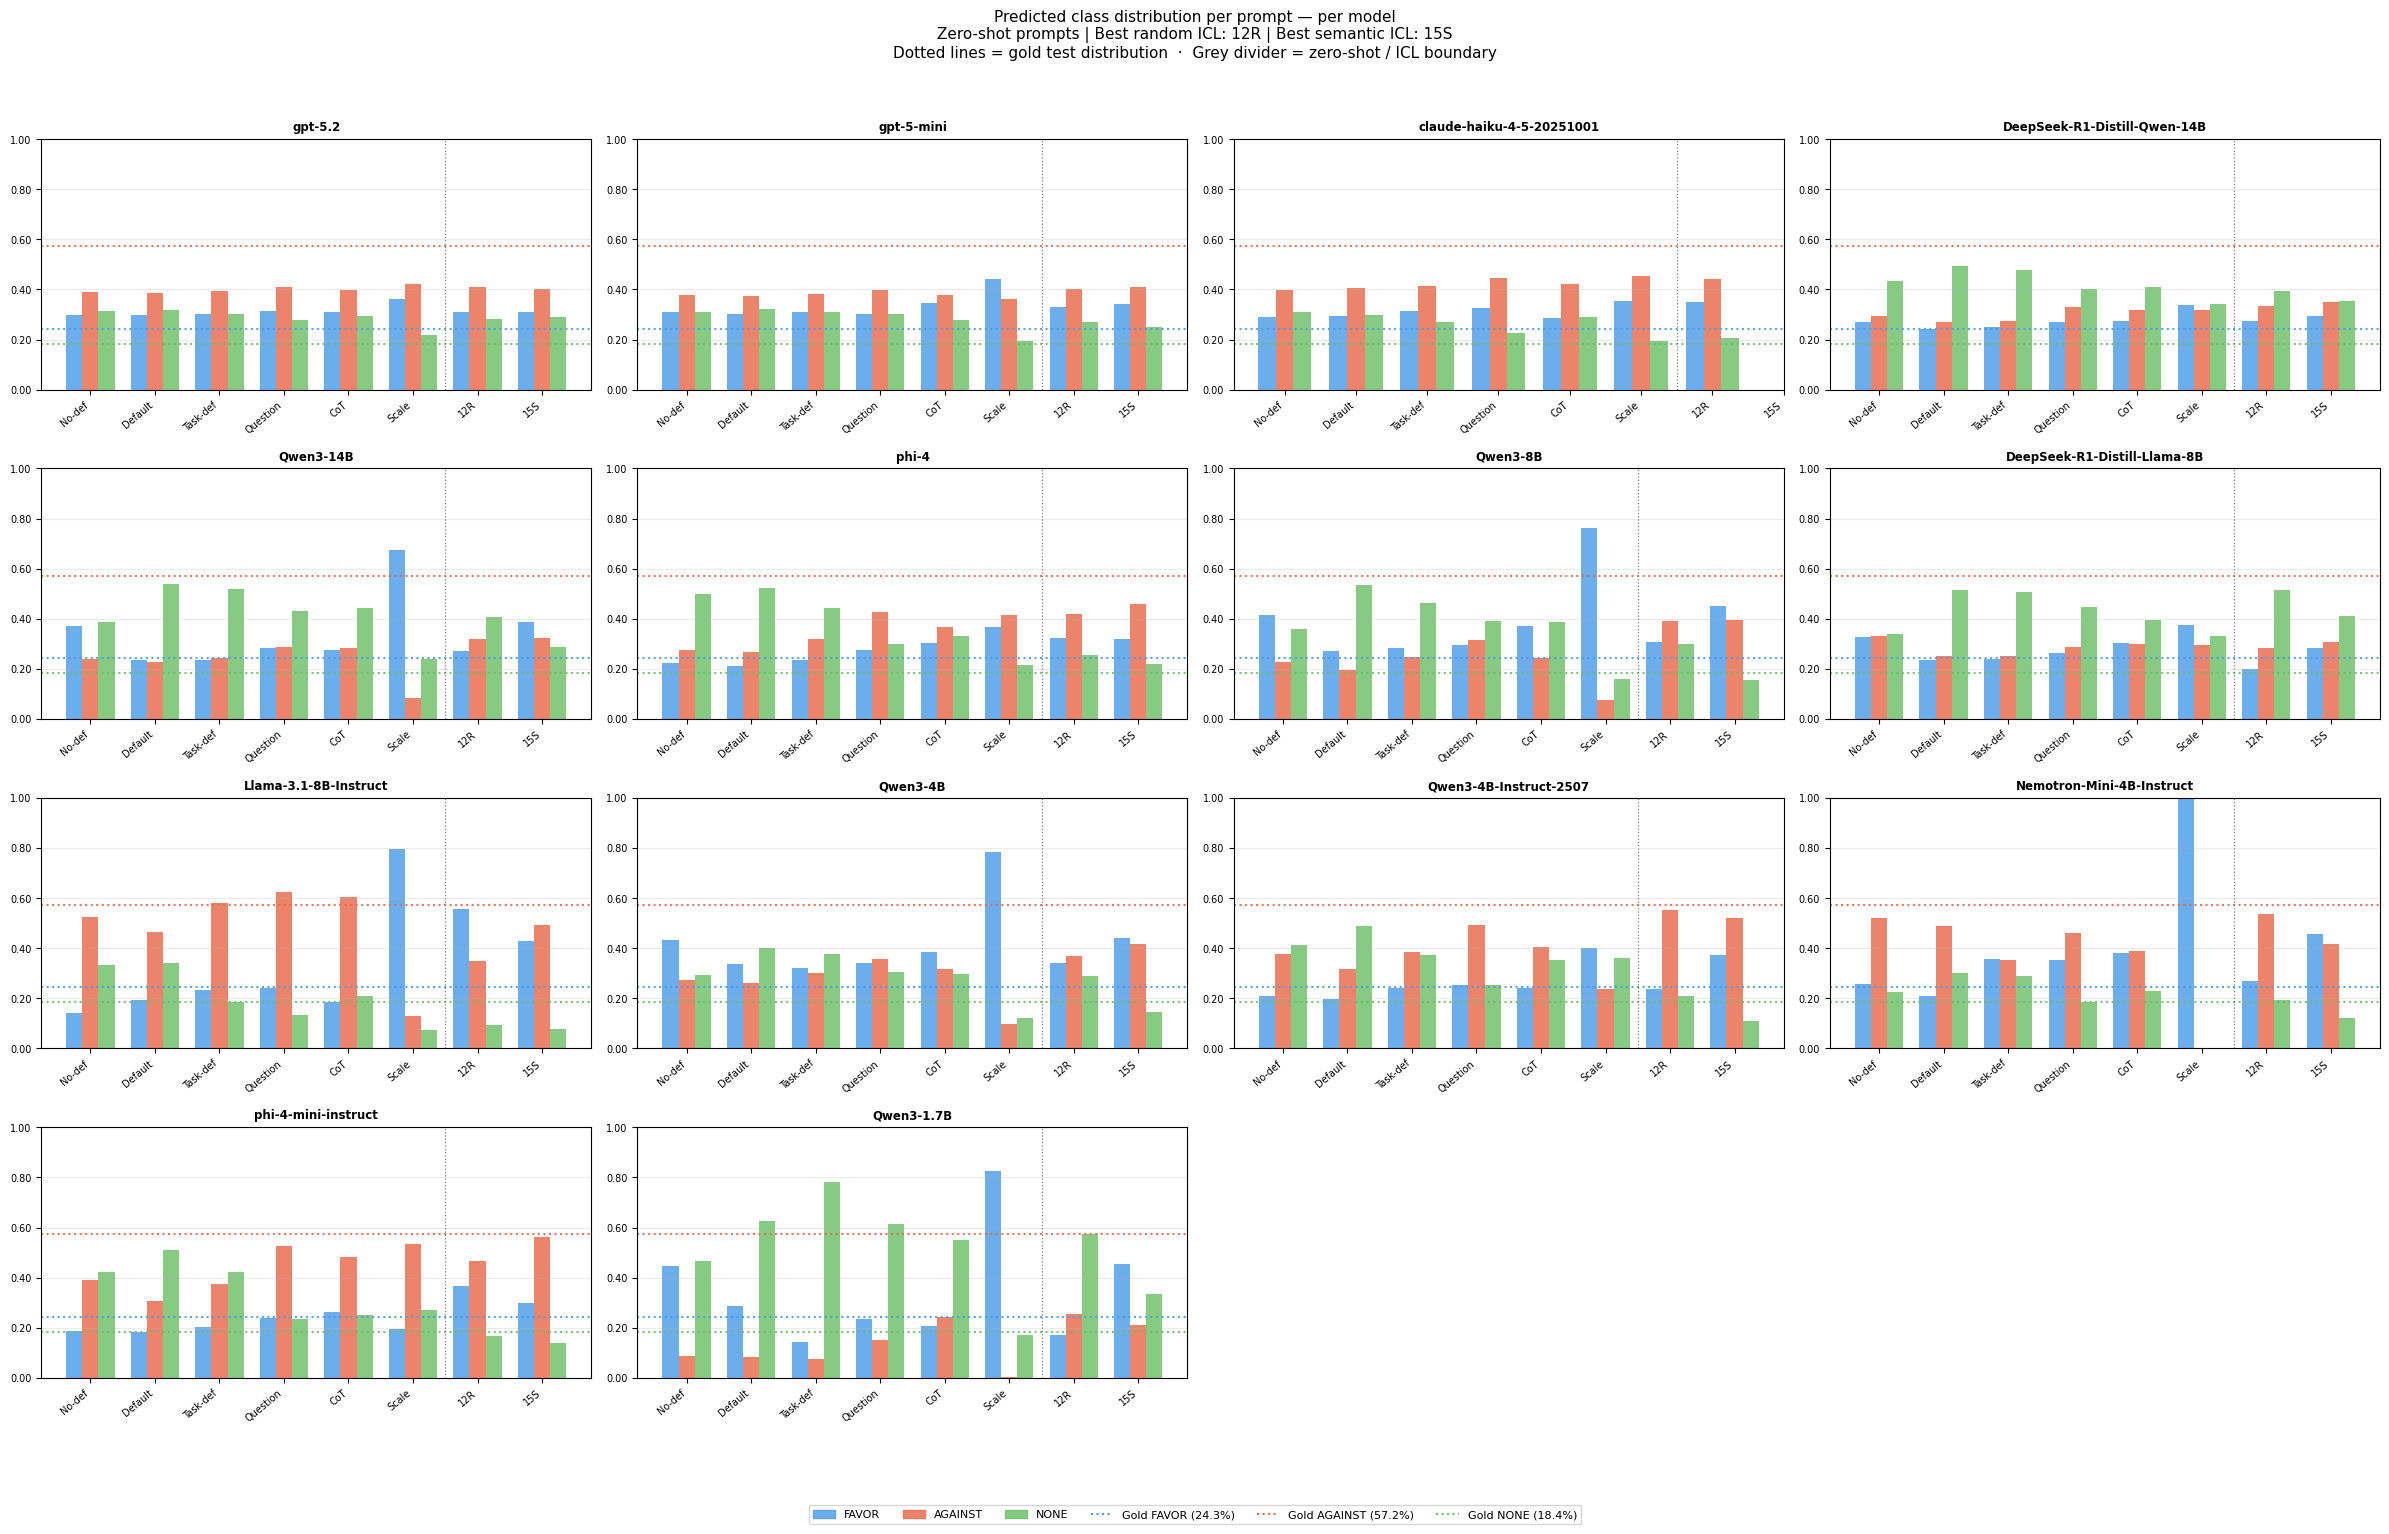

In [112]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import math

# ── Auto-pick best few-shot counts ────────────────────────────────────────────
rand_prompts = ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"]
sem_prompts  = ["semantic_icl_3","semantic_icl_6","semantic_icl_9","semantic_icl_12","semantic_icl_15"]

best_rand = llm_df[llm_df["prompt"].isin(rand_prompts)].groupby("prompt")["3class_macro_f1"].mean().idxmax()
best_sem  = llm_df[llm_df["prompt"].isin(sem_prompts)].groupby("prompt")["3class_macro_f1"].mean().idxmax()

print(f"Best random ICL: {PROMPT_LABELS_CHART[best_rand]}  |  Best semantic ICL: {PROMPT_LABELS_CHART[best_sem]}")

ZERO_SHOT_PROMPTS = [
    "default_no_label_definitions","default","task_definition",
    "question","cot","task_definition_scale",
]
SELECTED = ZERO_SHOT_PROMPTS + [best_rand, best_sem]
SEL_LABELS = [PROMPT_LABELS_CHART[p] for p in SELECTED]

GOLD_PCT   = {"FAVOR": 304/1249, "AGAINST": 715/1249, "NONE": 230/1249}
CLASSES    = ["FAVOR", "AGAINST", "NONE"]
DIST_COLS  = {"FAVOR": "pred_favor", "AGAINST": "pred_against", "NONE": "pred_none"}
CLASS_COLOR = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

# ── Filter dist_df to selected prompts ───────────────────────────────────────
dist_sel = dist_df[dist_df["prompt"].isin(SELECTED)].copy()

# model order from overall mean F3
models_plot = _ordered_models(llm_df)

n_models = len(models_plot)
n_cols   = 4
n_rows   = math.ceil(n_models / n_cols)

bw = 0.25
x  = np.arange(len(SELECTED))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 3.8))
fig.subplots_adjust(hspace=0.55, wspace=0.3)
axes_flat = axes.flatten()

for ax_idx, model in enumerate(models_plot):
    ax    = axes_flat[ax_idx]
    short = model.split("/")[-1] if "/" in model else model
    mdf   = dist_sel[dist_sel["model"] == model].set_index("prompt")

    for c_idx, cls in enumerate(CLASSES):
        col  = DIST_COLS[cls]
        vals = [mdf.loc[p, col] if p in mdf.index else np.nan for p in SELECTED]
        ax.bar(x + (c_idx - 1) * bw, vals, bw,
               color=CLASS_COLOR[cls], alpha=0.82, label=cls if ax_idx == 0 else "_")

        ax.axhline(GOLD_PCT[cls], color=CLASS_COLOR[cls],
                   linestyle=":", linewidth=1.5, alpha=0.9)

    ax.set_title(short, fontsize=8.5, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(SEL_LABELS, fontsize=7, rotation=40, ha="right")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="y", alpha=0.25)

    # divider between zero-shot and ICL
    ax.axvline(len(ZERO_SHOT_PROMPTS) - 0.5, color="grey", linestyle=":", linewidth=0.9)

# Hide unused axes
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

# Legend
class_patches = [
    mpatches.Patch(color=CLASS_COLOR[c], alpha=0.82, label=c) for c in CLASSES
]
gold_lines = [
    plt.Line2D([], [], color=CLASS_COLOR[c], linestyle=":", linewidth=1.5,
               label=f"Gold {c} ({GOLD_PCT[c]:.1%})")
    for c in CLASSES
]
fig.legend(
    handles=class_patches + gold_lines,
    loc="lower center", ncol=6, fontsize=8,
    bbox_to_anchor=(0.5, -0.02), frameon=True,
)

fig.suptitle(
    f"Predicted class distribution per prompt — per model\n"
    f"Zero-shot prompts | Best random ICL: {PROMPT_LABELS_CHART[best_rand]} | "
    f"Best semantic ICL: {PROMPT_LABELS_CHART[best_sem]}\n"
    f"Dotted lines = gold test distribution  ·  Grey divider = zero-shot / ICL boundary",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()


## Step 27: Per-target Confusion Transitions Heatmap

Same 6 key transitions as Step 17, broken out per target.
Rows = models, columns = transitions. One heatmap per target.
Reveals whether hedging (AGAINST→NONE) and agreeableness (FAVOR bias) are topic-conditioned.

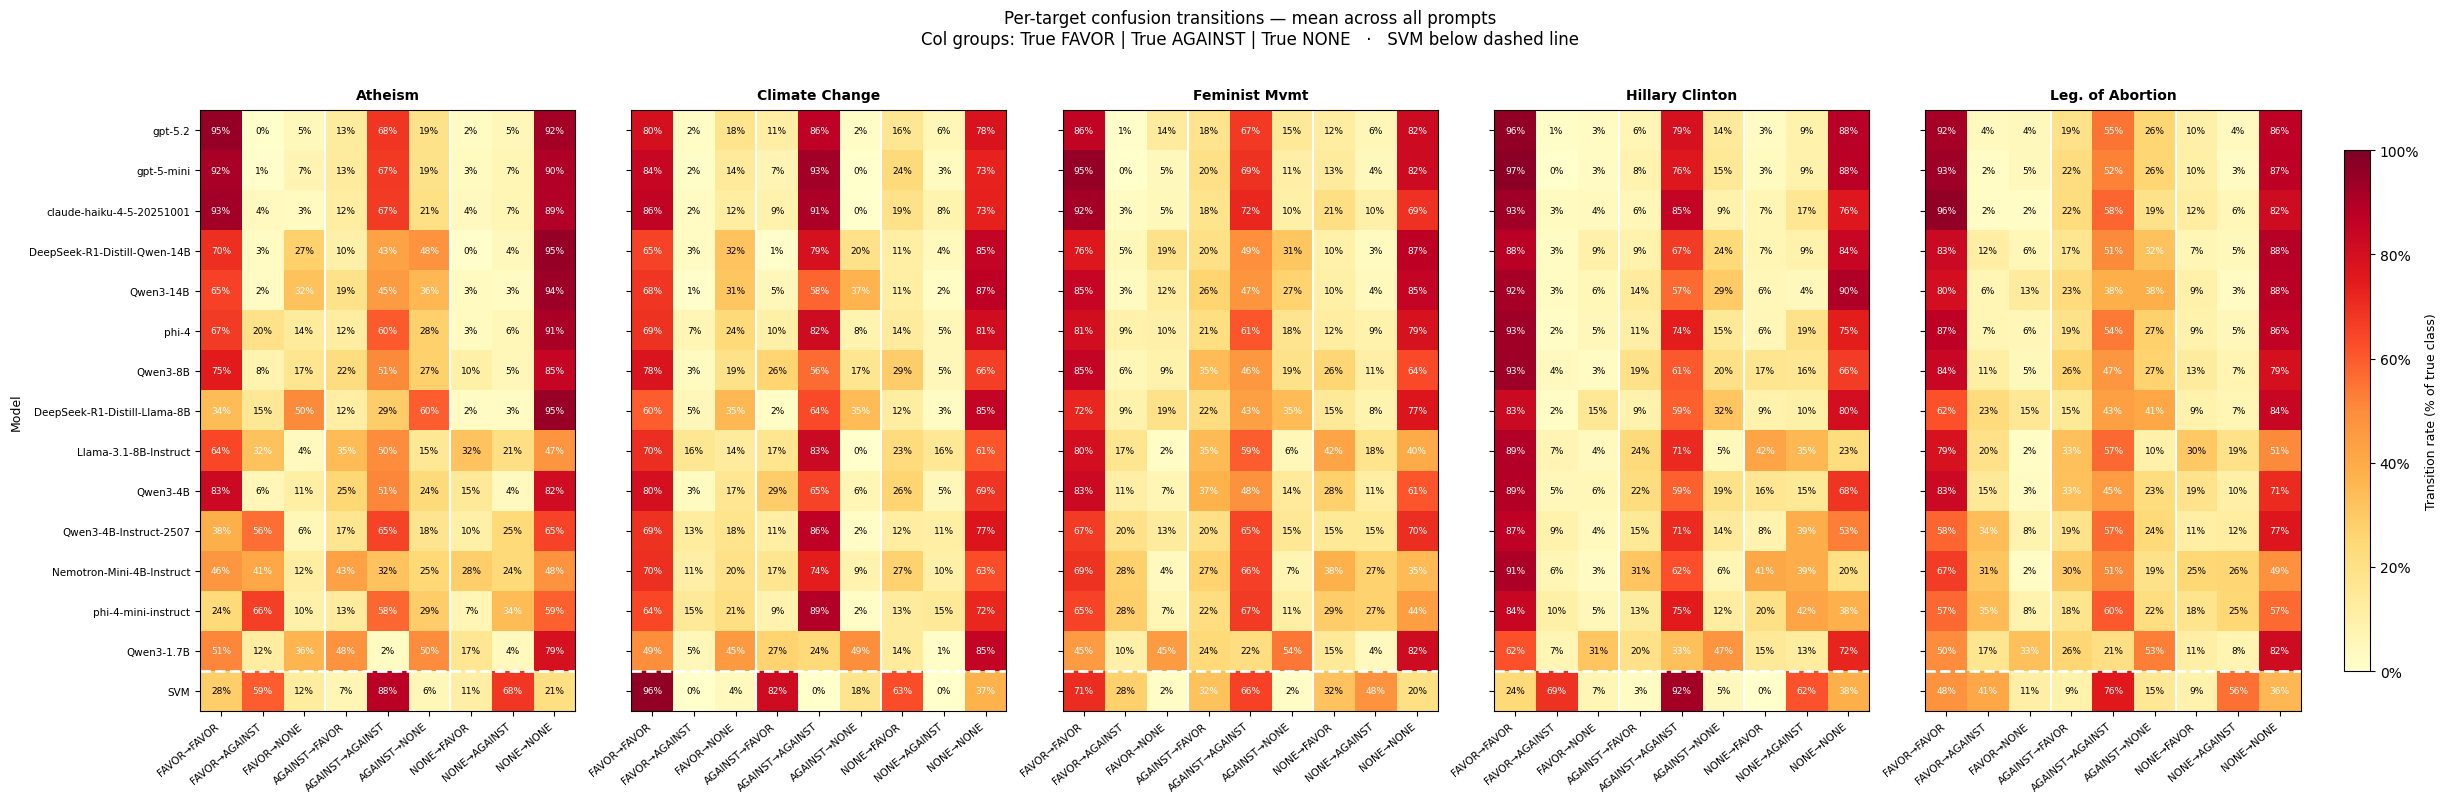

In [113]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import os

CLASSES    = ["FAVOR", "AGAINST", "NONE"]
KEY_TRANS = [
    "FAVOR→FAVOR",   "FAVOR→AGAINST",   "FAVOR→NONE",
    "AGAINST→FAVOR", "AGAINST→AGAINST", "AGAINST→NONE",
    "NONE→FAVOR",    "NONE→AGAINST",    "NONE→NONE",
]
TARGET_ORDER = [
    "Atheism", "Climate Change is a Real Concern",
    "Feminist Movement", "Hillary Clinton", "Legalization of Abortion",
]
TARGET_SHORT_FLAT = {
    "Atheism":                          "Atheism",
    "Climate Change is a Real Concern": "Climate Change",
    "Feminist Movement":                "Feminist Mvmt",
    "Hillary Clinton":                  "Hillary Clinton",
    "Legalization of Abortion":         "Leg. of Abortion",
}

# model order
model_order_plot = _ordered_models(llm_df)
model_labels_plot = [m.split("/")[-1] if "/" in m else m for m in model_order_plot]

# ── Compute per-model × per-target confusion transitions ─────────────────────
# rows: {model, target, AGAINST→NONE, ...}
trans_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_1249"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem  = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].astype(str).str.upper().str.strip()
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue
    for tgt in TARGET_ORDER:
        sub = df[df["query"] == tgt]
        if len(sub) < 10:
            continue
        yt, yp = sub["original_stance"].tolist(), sub["predicted_stance"].tolist()
        cm = confusion_matrix(yt, yp, labels=CLASSES).astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm  = np.divide(cm, row_sums, where=row_sums > 0)
        row = {"model": model, "target": tgt}
        for r_idx, tc in enumerate(CLASSES):
            for c_idx, pc in enumerate(CLASSES):
                row[f"{tc}→{pc}"] = cm_norm[r_idx, c_idx]
        trans_rows.append(row)

trans_df = pd.DataFrame(trans_rows)

# mean across prompts per model × target
trans_mean = (
    trans_df.groupby(["model", "target"])[KEY_TRANS]
    .mean()
    .reset_index()
)

# SVM per-target transitions
svm_trans = {}
for tgt in TARGET_ORDER:
    rows = [r for r in all_preds_f3 if r["target"] == tgt]
    yt = [r["true"] for r in rows]
    yp = [r["pred"] for r in rows]
    cm = confusion_matrix(yt, yp, labels=CLASSES).astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.divide(cm, row_sums, where=row_sums > 0)
    svm_row = {}
    for r_idx, tc in enumerate(CLASSES):
        for c_idx, pc in enumerate(CLASSES):
            svm_row[f"{tc}→{pc}"] = cm_norm[r_idx, c_idx]
    svm_trans[tgt] = svm_row

# ── Plot: 1 row × 5 cols, one heatmap per target ─────────────────────────────
n_models  = len(model_order_plot)
fig, axes = plt.subplots(1, 5, figsize=(28, max(5, n_models * 0.45 + 1.5)))
fig.subplots_adjust(wspace=0.15)

for col, tgt in enumerate(TARGET_ORDER):
    ax = axes[col]
    sub = trans_mean[trans_mean["target"] == tgt].copy()
    sub = sub.set_index("model")

    # build matrix: rows = models (order), cols = KEY_TRANS; last row = SVM
    data = []
    for model in model_order_plot:
        if model in sub.index:
            data.append([sub.loc[model, t] for t in KEY_TRANS])
        else:
            data.append([np.nan] * len(KEY_TRANS))
    # add SVM row
    data.append([svm_trans[tgt].get(t, np.nan) for t in KEY_TRANS])
    data = np.array(data)

    im = ax.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)

    ax.set_xticks(range(len(KEY_TRANS)))
    ax.set_xticklabels(KEY_TRANS, fontsize=7.5, rotation=40, ha="right")
    ax.set_yticks(range(n_models + 1))
    if col == 0:
        ax.set_yticklabels(model_labels_plot + ["SVM"], fontsize=7.5)
    else:
        ax.set_yticklabels([])

    # separator before SVM row
    ax.axhline(n_models - 0.5, color="white", linewidth=2, linestyle="--")

    # col group separators (AGAINST | FAVOR | NONE errors)
    for sep in [2.5, 5.5]:
        ax.axvline(sep, color="white", linewidth=1.5)

    # annotate cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                        fontsize=6.5, color="white" if v > 0.32 else "black")

    ax.set_title(TARGET_SHORT_FLAT[tgt], fontsize=10, fontweight="bold", pad=8)
    if col == 0:
        ax.set_ylabel("Model", fontsize=9)

# shared colorbar
cbar = fig.colorbar(im, ax=axes, fraction=0.012, pad=0.02)
cbar.set_label("Transition rate (% of true class)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

fig.suptitle(
    "Per-target confusion transitions — mean across all prompts\n"
    "Col groups: True FAVOR | True AGAINST | True NONE   ·   SVM below dashed line",
    fontsize=12, y=1.01,
)
plt.show()
